# Set-up

- Décrire l'intérêt des figures
- Spécifier le R^2_trial à partir de la specification du modèle joint (formule)

## Load libraries

In [82]:
#Set directory
directory="C:/Users/atanoh/Documents/2026/CA125"
setwd(directory)
#Install and load libraires
invisible(source("./src/librairies.r"))
# Load functions
invisible(source("./src/functions.r"))

## Load and clean dataset

In [ ]:
#Load dataset
ca125 <- read.csv("./data/MAOV_ca125_all.csv", sep=";")
ca125 <- ca125%>%mutate(id=paste(trialid,"_",patid)) 
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)


In [ ]:
#Clean dataset
#check time between first surgery and first measure
Sys.setlocale("LC_TIME", "C")
ca125$delay_surg_trt<-(as.Date(toupper(ca125$dotrt_begin), format = "%d%b%Y")-as.Date(toupper(ca125$dosurg1), format = "%d%b%Y"))
#delete patients with delay <7
ca125<- ca125[!ca125$id %in% unique(ca125$id[ca125$delay_surg_trt < 7 & !is.na(ca125$delay_surg_trt)]),]

[1] "C"

In [ ]:
# Clean first progression column
ca125 <- ca125 %>%
  mutate(
    dor = as.Date(toupper(dor), format = "%d%b%Y"),
    dofirst_prog = as.Date(toupper(dofirst_prog), format = "%d%b%Y"),
    dofirst_prog = if_else(
      is.na(dofirst_prog) & !is.na(dor),
      dor + pfs_time_m * 30.4375,
      dofirst_prog
    )
  )
ca125 <- ca125 %>%
  mutate(
    dotrt_begin = as.Date(toupper(dotrt_begin), format = "%d%b%Y"),
    donext_trt = as.Date(toupper(donext_trt), format = "%d%b%Y"),
    do_CA125 = as.Date(toupper(do_CA125), format = "%d%b%Y")
  )

In [ ]:
#delete measures after progression 
ca125<-ca125 %>%
  filter( (trialid != "MRC-ICON7" & do_CA125 <= dofirst_prog) |
        (trialid == "MRC-ICON7" & time_ca125<=pfs_time_m * 30.4375))

In [ ]:
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
8163,13,81449


In [ ]:
#Create variables
ca125$trt_bin<- if_else(ca125$trt=="Standard regimen", 0,1)
ca125["os_time_d"]<-ca125$os_time_m*30.4375
ca125["pfs_time_d"]<-ca125$pfs_time_m*30.4375
ca125["os_statut"]<-factor(ifelse(ca125$os_status=='Yes', 1, 0), levels=c(0,1))
ca125["pfs_statut"]<-factor(ifelse(ca125$PFS_status=='Yes', 1, 0), levels=c(0,1))
#restrict data                             
colonnes<-c("trialid","patid","id",'trt','dor','CA125_mes','do_CA125','id_temp','dotrt_begin', "donext_trt",'dotrt_end',"time_ca125",'os_status','OS_time','PFS_status','PFS_time',"nb_mesures",
"ca125_base",'Visit','pfs_time_m',"pfs_time_d",'os_time_m',"os_time_d",'group','country','maov_group','dob','age','figo','figo4c',"trt_bin","os_statut","pfs_statut")
ca125_all_6 <- ca125[colonnes]%>%
  filter(time_ca125 <= 188) %>%
  group_by(id) %>%
  filter(n() > 1) %>%
  ungroup()
ca125_all_6["id_num"]<- as.numeric(as.factor(ca125_all_6$id))
ca125_all_6["trialid_num"]<- as.numeric(as.factor(ca125_all_6$trialid))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [ ]:
ca125_all_6 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
7933,13,47256


**Summarise data**

In [ ]:
ca125_all_6 %>%
  group_by(trialid) %>%
  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),

     # percentage deaths
    mean_baseline = round(mean(ca125_base, na.rm = TRUE),2),
    
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

trialid,status,nb_measures,nb_patients,mean_ca125,mean_baseline,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Maintenance,648,194,96.12,31.60,17.13,52.62,330.00,267.50
CCTG-OV.16,No maintenance,5517,731,222.35,721.71,72.05,84.74,1443.99,504.99
DoCaCel,Maintenance,40,19,186.32,346.38,72.50,77.50,995.50,374.50
EORTC-55041,Maintenance,1982,772,74.86,25.07,43.90,74.42,1351.00,424.00
GINECO-2007,Intensification therapy,613,109,313.07,870.53,83.85,92.50,975.00,445.00
JGOG-3016,Intensification therapy,3240,552,312.25,1022.00,46.57,65.25,1837.00,841.00
JGOG-3017,No maintenance,3497,608,67.62,129.05,18.84,26.19,1195.00,1100.00
MITO-7,Intensification therapy,1398,517,206.89,473.78,16.95,51.65,629.00,490.00
MRC-ICON7,Maintenance,10017,1471,113.08,376.65,46.14,71.46,1493.00,576.00


*Presentation of data and variables of interest (appendix)*

In [ ]:
ca125_all_6 %>%  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

status,nb_measures,nb_patients,mean_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Intensification therapy,47256,7933,204.4,46.07,68.61,959,527


# Modeling CA125

## Evolution of CA-125

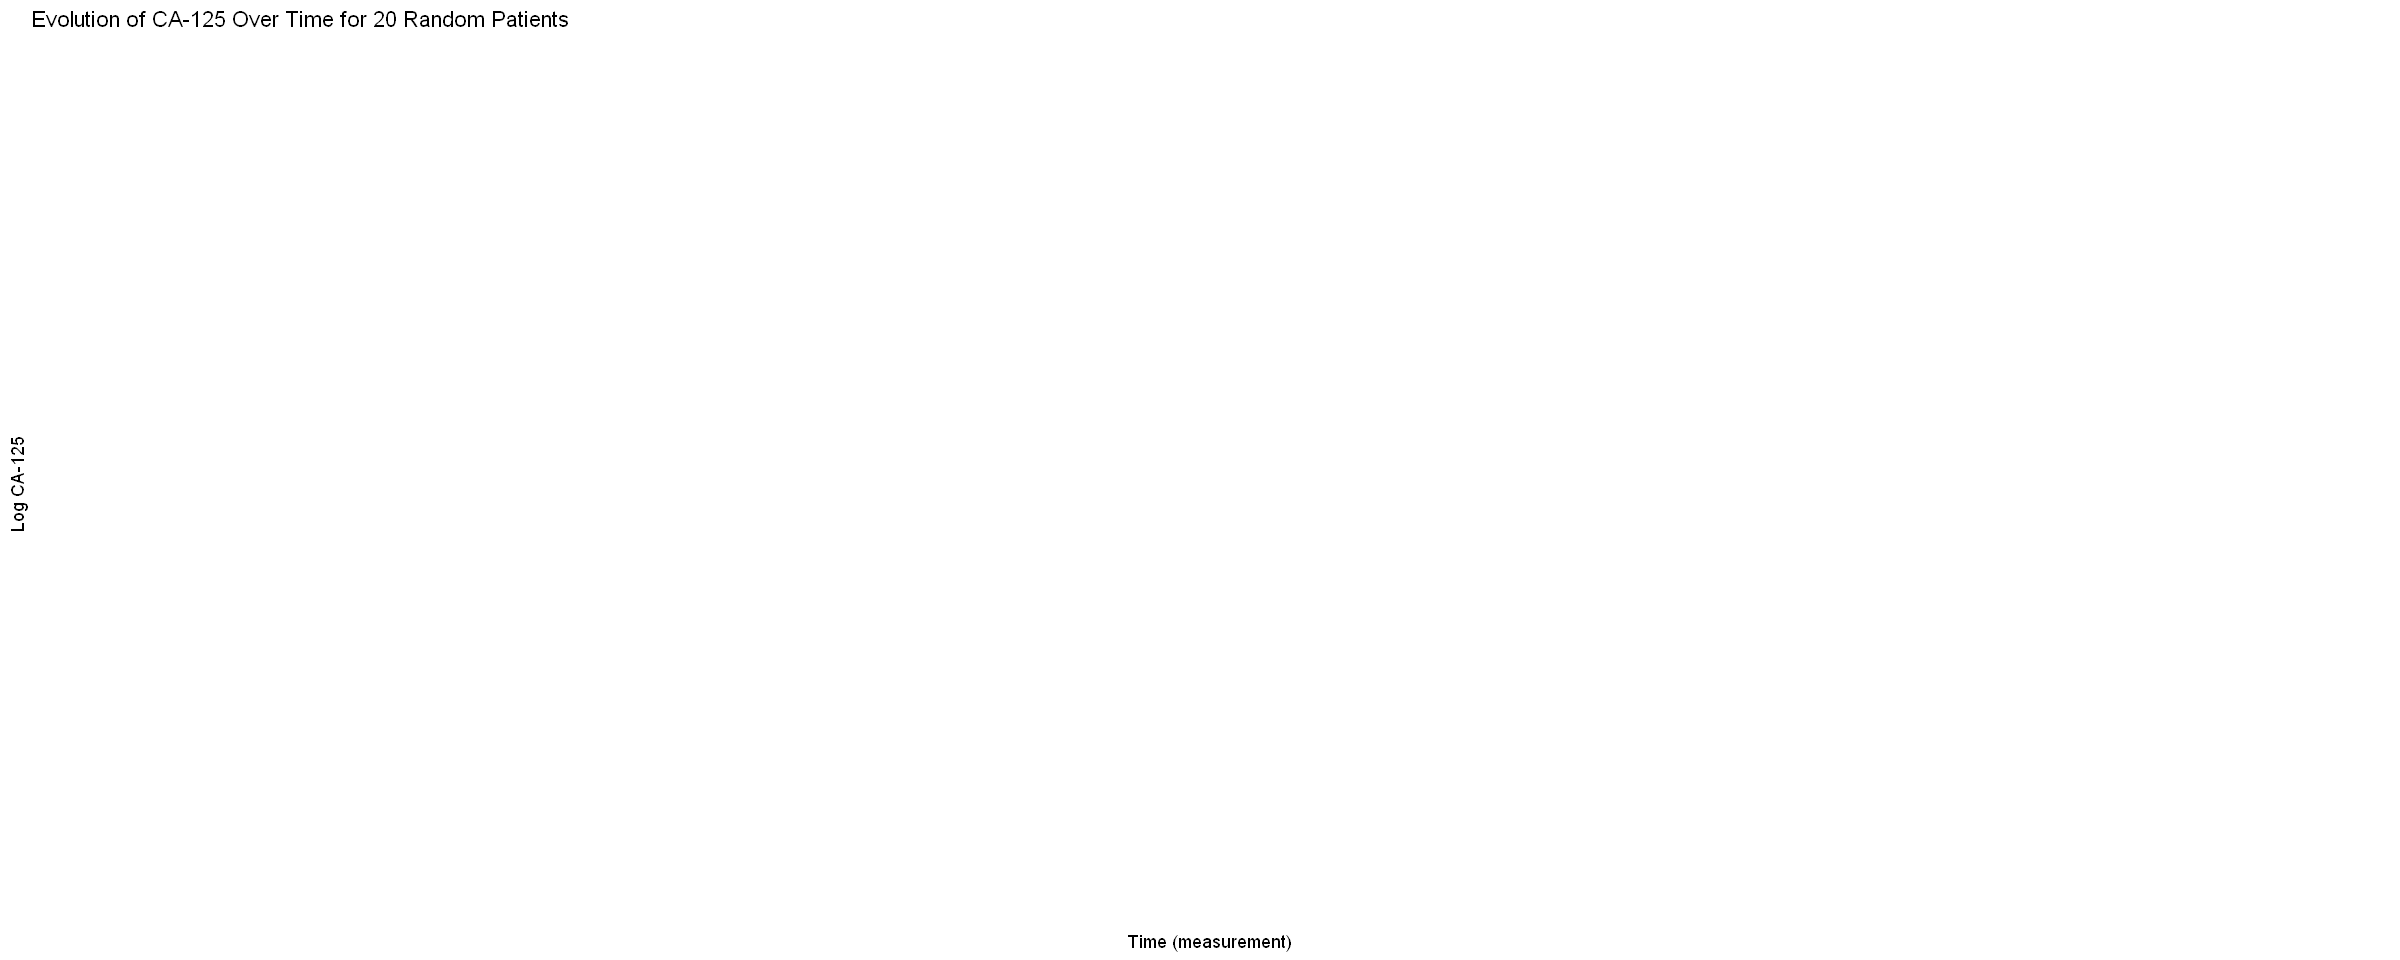

In [ ]:
# set.seed(123)
# Select 20 random patients
selected_ids <- ca125_all_6 %>%
  distinct(id) %>%
  sample_n(20) %>%
  pull(id)
subset_data <- ca125_all_6[ca125_all_6$time_ca125<=90,] %>%
  filter(patid %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time for 20 Random Patients",
    x = "Time (measurement)", 
    y = "Log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [ ]:
# Compute trends per patient over 90 days of observation
df_trends_180 <- ca125_all_6%>%
  group_by(id) %>%
  summarise(trend_cat = trend(log_ca125, time_ca125), .groups = "drop")

# Join back to the original dataset
df_180 <- ca125_all_6 %>%
  left_join(df_trends_180, by = "id")
table(df_180$trend_cat)



decreasing increasing 
     43446       3810 

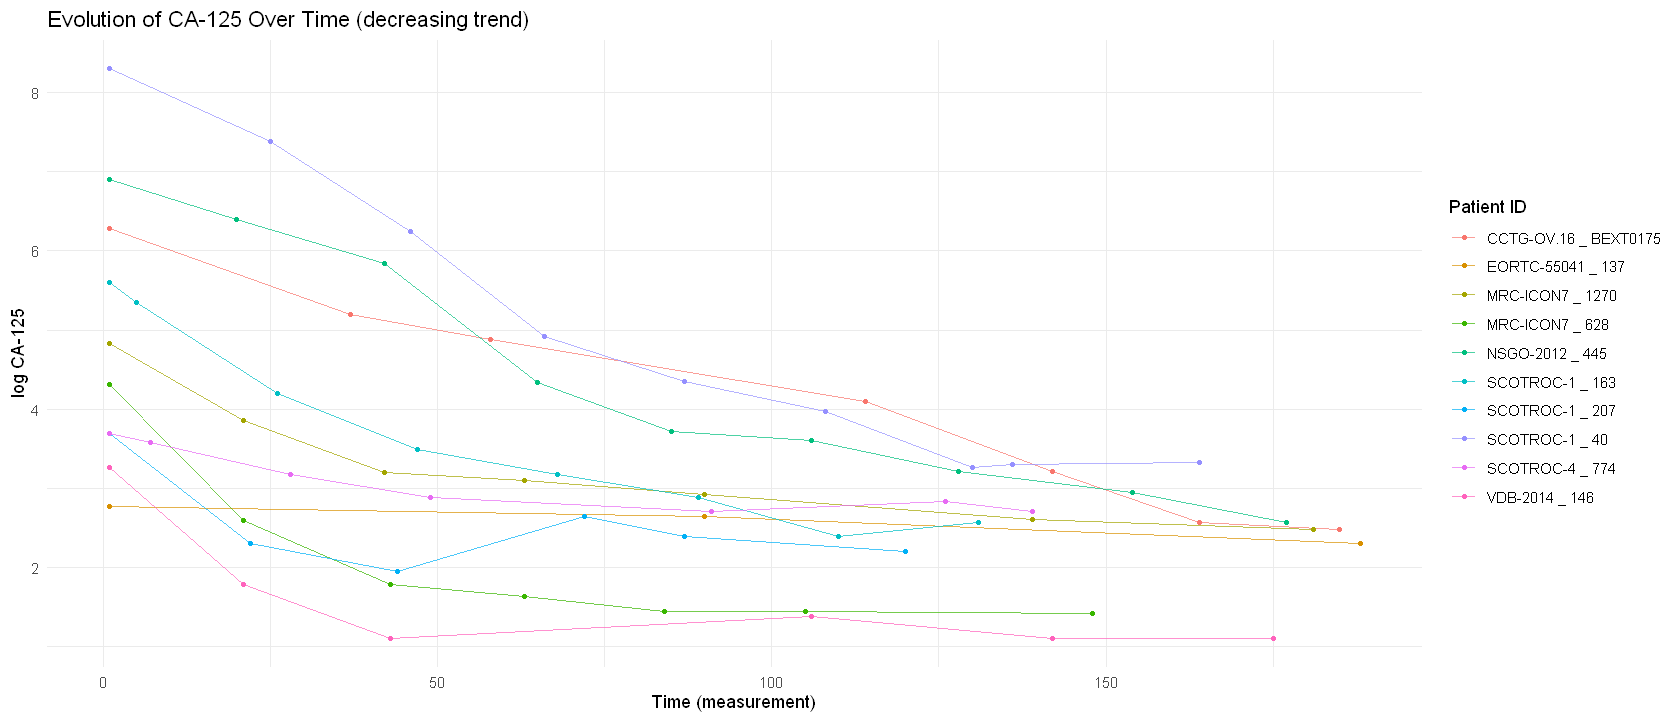

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)
selected_ids <- df_180[df_180$trend_cat=="decreasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (decreasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

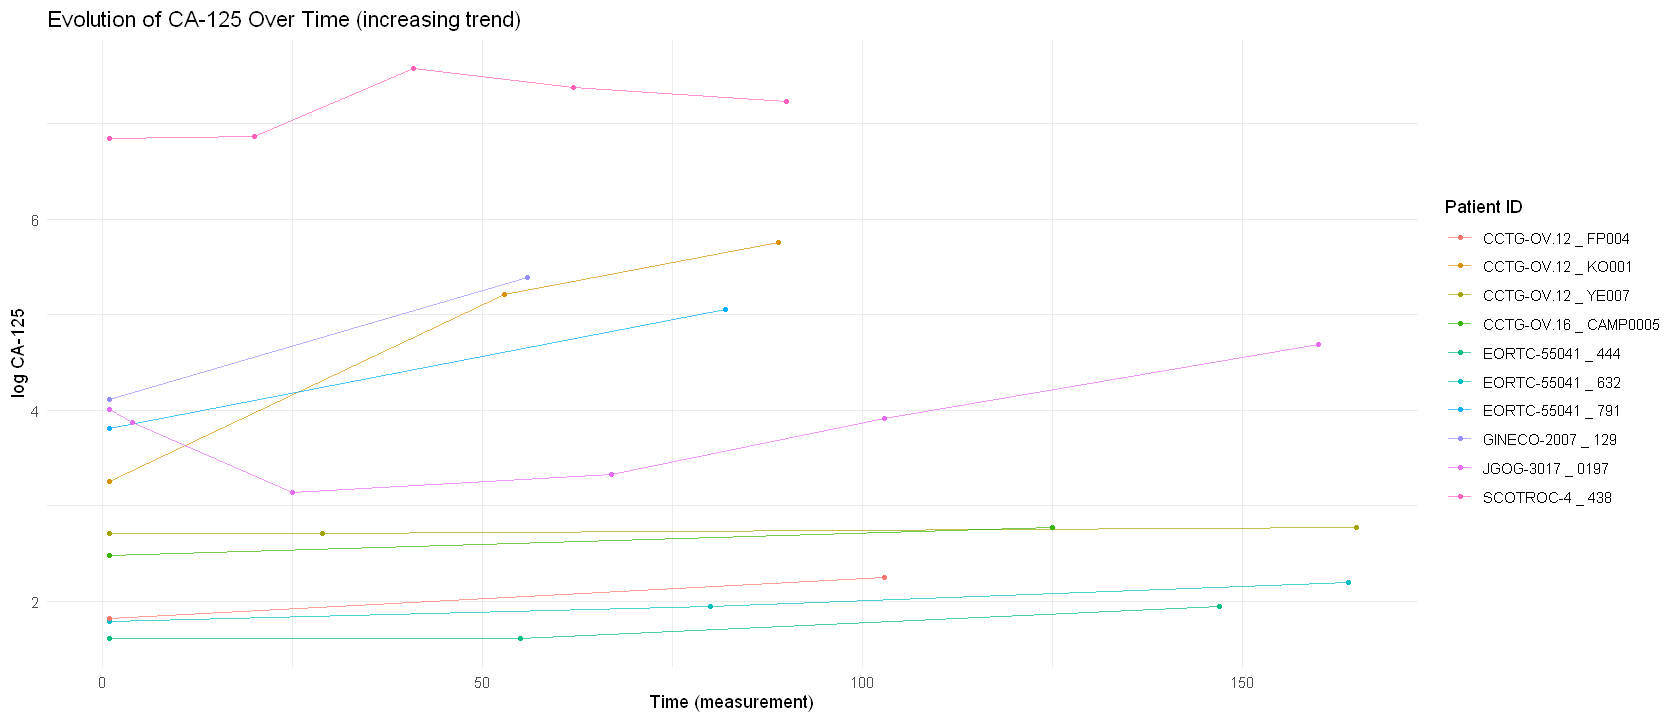

In [ ]:
selected_ids <- df_180[df_180$trend_cat=="increasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (increasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

**Summarise CA-125 values**

In [ ]:
ca125_all_6 %>%
  
  # keep repeated measures if you want ALL CA125 values
  group_by(trialid, trt) %>%
  
  summarise(
    
    n_measures = n(),
    n_patients = n_distinct(id),
    
    minca125 = min(CA125_mes, na.rm = TRUE),
    
    q1_ca125 = quantile(CA125_mes, 0.25, na.rm = TRUE),
    
    mean_ca125 = mean(CA125_mes, na.rm = TRUE),
    
    q3_ca125 = quantile(CA125_mes, 0.75, na.rm = TRUE),
    
    max_ca125 = max(CA125_mes, na.rm = TRUE),
        # percentage deaths
    pct_death = mean(os_statut == 1, na.rm = TRUE) * 100,
    # percentage progression
    pct_progression = mean(pfs_statut == 1, na.rm = TRUE) * 100,
    # median OS time
    median_os_time_d = median(os_time_d, na.rm = TRUE),
    # median PFS time
    median_pfs_time_d = median(pfs_time_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  arrange(trialid, trt)

trialid,trt,n_measures,n_patients,minca125,q1_ca125,mean_ca125,q3_ca125,max_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Investigational regimen,326,98,1.00,7.270,63.48276,27.675,3865.0,13.19018,56.74847,332.0001,265.9994
CCTG-OV.12,Standard regimen,322,96,0.60,7.000,129.15689,28.850,7027.0,21.11801,48.44720,327.9991,269.0005
CCTG-OV.16,Investigational regimen,2711,372,0.39,11.000,254.31692,128.000,12083.0,72.44559,85.06086,1457.9867,482.0083
CCTG-OV.16,Standard regimen,2806,359,0.21,11.000,191.45644,94.525,11800.0,71.66785,84.42623,1439.9981,524.0120
DoCaCel,Investigational regimen,16,8,7.00,9.000,126.43750,53.750,1046.0,62.50000,62.50000,791.0000,354.0000
DoCaCel,Standard regimen,24,11,9.00,11.000,226.25000,156.000,2100.0,79.16667,87.50000,1352.0000,374.5000
EORTC-55041,Investigational regimen,993,388,1.00,8.000,58.35952,23.000,3812.0,46.42497,76.33434,1340.0000,408.0000
EORTC-55041,Standard regimen,989,384,1.00,7.000,91.42568,23.000,14220.0,41.35490,72.49747,1372.0000,434.0000
GINECO-2007,Investigational regimen,292,48,4.00,16.000,253.08925,196.500,5180.0,86.98630,96.57534,1026.0000,490.0000


*Variables of interest per treatment group (should comparison tests? )* 

**Longitidunal model**

With splines :
- s trials
- $n_i$ patients in trial $i$, $n = \sum_{i=1}^{s} n_i$ the total number of patients
- $m_{ij}$ the number of measures for patient j in study i, $m_{i}=\sum_{j=1}^{n_i} m_{ij}$ the total number of observations in trial $i$, $N=\sum_{i=1}^{s} m_i=\sum_{i=1}^{s}\sum_{j=1}^{n_i} m_{ij}$ the total number of observations
- $y(t_{ijk})$ the $k^{th}$ value $k \in {1,...,m_{ij}}$ of biomarker CA-125 for patient $j$, $j \in {1,...,n_i}$, in study $i$, $i \in {1,...,s}$
- 
$$
T_{ij}=
\begin{cases} 
1 & \text{if patient $j$ in trial $i$ received the treatment} 
\\ 0 & \text{otherwise}
\end{cases}
$$

Mixed-effects model for varataion of $y$:
$
log[y(t_{ijk})]= f(t_{ijk}) +\epsilon_{ijk}
$, 
with:
- $ f(t)= (\theta_{1}+b_{1i}+b_{1ij}) + (\theta_{4}+b_{4ij})t+ \sum_{k=0}^1 (\theta_{k+2}+ b_{k+2,ij})B_{k+2}(t)+ (\theta_{5}+ b_{5,i})T_{ij}*t+ \sum_{k=0}^1 (\theta_{k+6}+ b_{k+6,i}) T_{ij}*B_{k+2}(t)$; $B_{k+2}(t) = d_{k} - d_2; d_k=\frac{(t-q_k(t))_{+}^3 - (t-q_3(t))_{+}^3}{q_k(t) - q_3(t)} \text{ , } k \in\ \{0,1\}$
- $x_+ = max (0, x)  $,
- $q_0(t), q_1(t), q_2(t) \text{ and } q_3(t)  \text{ are quantiles of t at 18\%, 22\%, 66\%, and 98\%} $
- $(b_{1i}, b_{5i},b_{6i},b_{7i})^\top \sim N(0, \phi)$, $\phi = \begin{pmatrix} \sigma_{1}^2 & \sigma_1\sigma_5 &\sigma_1\sigma_6 & \sigma_1\sigma_7\\ \sigma_1\sigma_5 & \sigma_{5}^2 & \sigma_5\sigma_6 & \sigma_5\sigma_7\\ \sigma_1\sigma_6 & \sigma_5\sigma_6 & \sigma_{6}^2& \sigma_6\sigma_7 \\ \sigma_1\sigma_7 & \sigma_5\sigma_7 & \sigma_6\sigma_7 & \sigma_{7}^2 \end{pmatrix}$  (random effect at study level)
- $ (b_{1ij},b_{4ij},b_{2ij}, b_{3ij})^t \sim N(0, D)$, $D = \begin{pmatrix} \sigma_{b1}^2 & \sigma_{b1b4} & \sigma_{b1b2} & \sigma_{b1b3} \\ \sigma_{b1b4} & \sigma_{b4}^2 &  \sigma_{b2b4} & \sigma_{b3b4} \\ \sigma_{b1b2} & \sigma_{b2b4} &\sigma_{b2}^2 & \sigma_{b2b3} \\ \sigma_{b1b3} & \sigma_{b3b4} & \sigma_{b2b3} & \sigma_{b3}^2 \end{pmatrix}$(random effects at patient-level)
- $\epsilon_{ijk} \sim N(0, \sigma^2_\epsilon I_N)$


**Conditional BLUP for patient-level random effects**:

- $\theta=(\theta_1 \text{  } \theta_4 \text{  } \theta_2 \text{  } \theta_3 \text{  } \theta_5 \text{  } \theta_6 \text{  } \theta_7)^T$

Matricial form: $ y= X\theta + Z_sb_s + Z_{n}b_{n} + \epsilon$, with :
$
y =
\begin{pmatrix}
y(t_{111}) \\
y(t_{112}) \\
\vdots \\
y(t_{11 m_{11}}) \\
y(t_{121}) \\
\vdots \\
y(t_{1 n_1 m_{1m=n_1}}) \\
\vdots \\
y(t_{s n_s m_{sn_s}})
\end{pmatrix}
\in \mathbb{R}^{N},
\qquad
$,
$
X =
\begin{pmatrix}
1 & t_{111} & B_2(t_{111}) & B_3(t_{111}) & T_{11}*t_{111} & T_{11}*B_2(t_{111}) & T_{11}*B_3(t_{111}) \\
1 & t_{112} & B_2(t_{112}) & B_3(t_{112}) & T_{11}*t_{112} & T_{11}*B_2(t_{112}) & T_{11}*B_3(t_{112}) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
1 & t_{11 m_{11}} & B_2(t_{11 m_{11}}) & B_3(t_{11 m_{11}}) & T_{11}*t_{11 m_{11}} & T_{11}*B_2(t_{11 m_{11}}) & T_{11}*B_3(t_{11 m_{11}}) \\
1 & t_{121} & B_2(t_{121}) & B_3(t_{121}) & T_{12}*t_{121} & T_{12}*B_2(t_{121}) & T_{12}*B_3(t_{121})\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & t_{s n_s m_{sn_s}} & B_2(t_{s n_s m_{sn_s}}) & B_3(t_{s n_s m_{sn_s}}) & T_{sn_s}*t_{t_{s n_s m_{sn_s}}} & T_{sn_s}*B_2(t_{t_{s n_s m_{sn_s}}}) & T_{sn_s}*B_3(t_{t_{s n_s m_{sn_s}}})
\end{pmatrix}
\in \mathbb{R}^{N \times 7}
$
- $b_s \sim N(0, \Phi)$, $\Phi = \mathrm{diag}(\phi,...,\phi) \in \mathbb{R}^{6s \times 6s}$ (study-level random intercept)
$$
b_s =
\begin{pmatrix}
b_{11} & b_{51} &  b_{61}& b_{71} \\
b_{12} & b_{52} &  b_{62}& b_{72}  \\
\vdots & \vdots & \vdots & \vdots \\
b_{1s} & b_{5s} & b_{6s} &  b_{7s}
\end{pmatrix}
\in \mathbb{R}^{s \times 4}
$$
- $b_{n} \sim N(0, \Delta)$ (patient-level random intercept+slope), $
\Delta = \mathrm{diag}(D,...,D) \in \mathbb{R}^{5n \times 5n}
$

$$
b_{n} =
\begin{pmatrix}
b_{1,11} \\
b_{4,11} \\
b_{2,11} \\
b_{3,11} \\
b_{1,12} \\
b_{4,12} \\
b_{2,12} \\
b_{3,12} \\
\vdots \\
b_{1,s n_s} \\
b_{4,s n_s} \\
b_{2,s n_s}\\
b_{3,s n_s}
\end{pmatrix}
\in \mathbb{R}^{4n},
\qquad
$$

- $\epsilon \sim N(0, \sigma^2_{\epsilon}I_N)$

$\boxed{Var(y)=V=Z_s \Phi Z_s^T + Z_{n}\Delta Z_{n}^T + \sigma^2_{\epsilon}I_N}$\
with:
- $ Z_s =\begin{pmatrix}\mathbf{Z}_{s_1} & 0 & \cdots & 0 \\0 & \mathbf{Z}_{s_2} & \cdots & 0 \\\vdots & \vdots & \ddots & \vdots \\0 & 0 & \cdots & \mathbf{Z}_{s_s}\end{pmatrix} \in \mathbb{R}^{N \times 6s}$
. For trial $i$, $ Z_{s_i} =\begin{pmatrix}1 & T_{i1}*t_{i11} & T_{i1}*B_2(t_{i11}) & T_{i1}*B_3(t_{i11})\\1 & T_{i1}*t_{i12} & T_{i1}*B_2(t_{i12}) & T_{i1}*B_3(t_{i12}) \\\vdots & \vdots & \vdots\\1 & T_{in_i}*t_{in_im_i} & T_{in_i}*B_2(t_{in_im_i}) & T_{in_i}*B_3(t_{in_im_i}) \end{pmatrix}\in \mathbb{R}^{m_{i} \times 4}$

For patient $(i,j)$,:

$
Z_{ij}=\begin{pmatrix}1 & t_{ij1} & B_2(t_{ij1}) & B_3(t_{ij1})\\1 & t_{ij2}&  B_2(t_{ij2}) & B_3(t_{ij2})\\\vdots & \vdots & \vdots\\1 & t_{ijm_{ij}}& B_2(t_{ijm_{ij}}) & B_3(t_{ijm_{ij}})\end{pmatrix}\in \mathbb{R}^{m_{ij} \times 4}$, 
$
Z_{n}=\begin{pmatrix}Z_{11} & 0 & \cdots & 0\\0 & Z_{12} & \cdots & 0\\\vdots & \vdots & \ddots & \vdots\\0 & 0 & \cdots & Z_{s n_s}\end{pmatrix} \in \mathbb{R}^{N \times 4n}
$

$$
\widehat{b}_{n} = \Delta Z_{n}^\top V^{-1}(y-X\hat{\theta})
$$
$
\begin{pmatrix}
\hat b_{1ij} \\
\hat b_{4ij} \\
\hat b_{2ij}\\
\hat b_{3ij}
\end{pmatrix}
=[\Delta]_{ij}\sum_{k=1}^{m_{ij}}\begin{pmatrix}1\\ t_{ijk} \\B_2(t_{ijk}) \\B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$


**BLUP for Study-Level Random Effect**\
$$
\widehat{b}_{s} = \Phi Z_s^\top V^{-1} (y-X\hat{\theta}) 
$$
$
\begin{pmatrix}
\hat b_{1i} \\
\hat b_{5i} \\
\hat b_{6i}\\
\hat b_{7j}
\end{pmatrix}
=[\Phi]_{i} \sum_{j=1}^{n_i} \sum_{k=1}^{m_{ij}}\begin{pmatrix}1 \\T_{ij}*t_{ijk} \\T_{ij}*B_2(t_{ijk}) \\T_{ij}*B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$



**Fixed Effects Estimate**\
Stack all data across studies:
$$
\hat{\beta} = (\mathbf{X}^\top \mathbf{V}^{-1} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{V}^{-1} \mathbf{y}
$$

In [ ]:
internal_knots <- with(ca125_all_6,quantile(time_ca125, probs = c(0.22, 0.66)))
boundary_knots <- with(ca125_all_6,quantile(time_ca125, probs = c(0.18, 0.98)))
# ncs_trt_all <- lmer(
#   log(CA125_mes) ~ ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)+ trt_bin:ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)+
#     (ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots) | id)+ (trt_bin:ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)|trialid),
#   data = ca125_all_6,
#   control = lmerControl(
#     optimizer = "bobyqa",
#     optCtrl = list(maxfun = 2e5)
#   )
# )
# attr(terms(ncs_trt_all), "predvars")
# saveRDS(ncs_trt_all, file = "./results/models/lmm.rds")


In [ ]:
ncs_trt_all <- readRDS(("./results/models/lmm.rds"))
summary(ncs_trt_all)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
log(CA125_mes) ~ ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) +  
    trt_bin:ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) +  
    (ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) |  
        id) + (trt_bin:ns(time_ca125, knots = internal_knots,  
    Boundary.knots = boundary_knots) | trialid)
   Data: ca125_all_6
Control: lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e+05))

REML criterion at convergence: 93236.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-15.0579  -0.3061  -0.0159   0.2809   9.8233 

Random effects:
 Groups  
 id      
         
         
         
 trialid 
         
         
         
 Residual
 Name                                                                            
 (Intercept)                                                                     
 

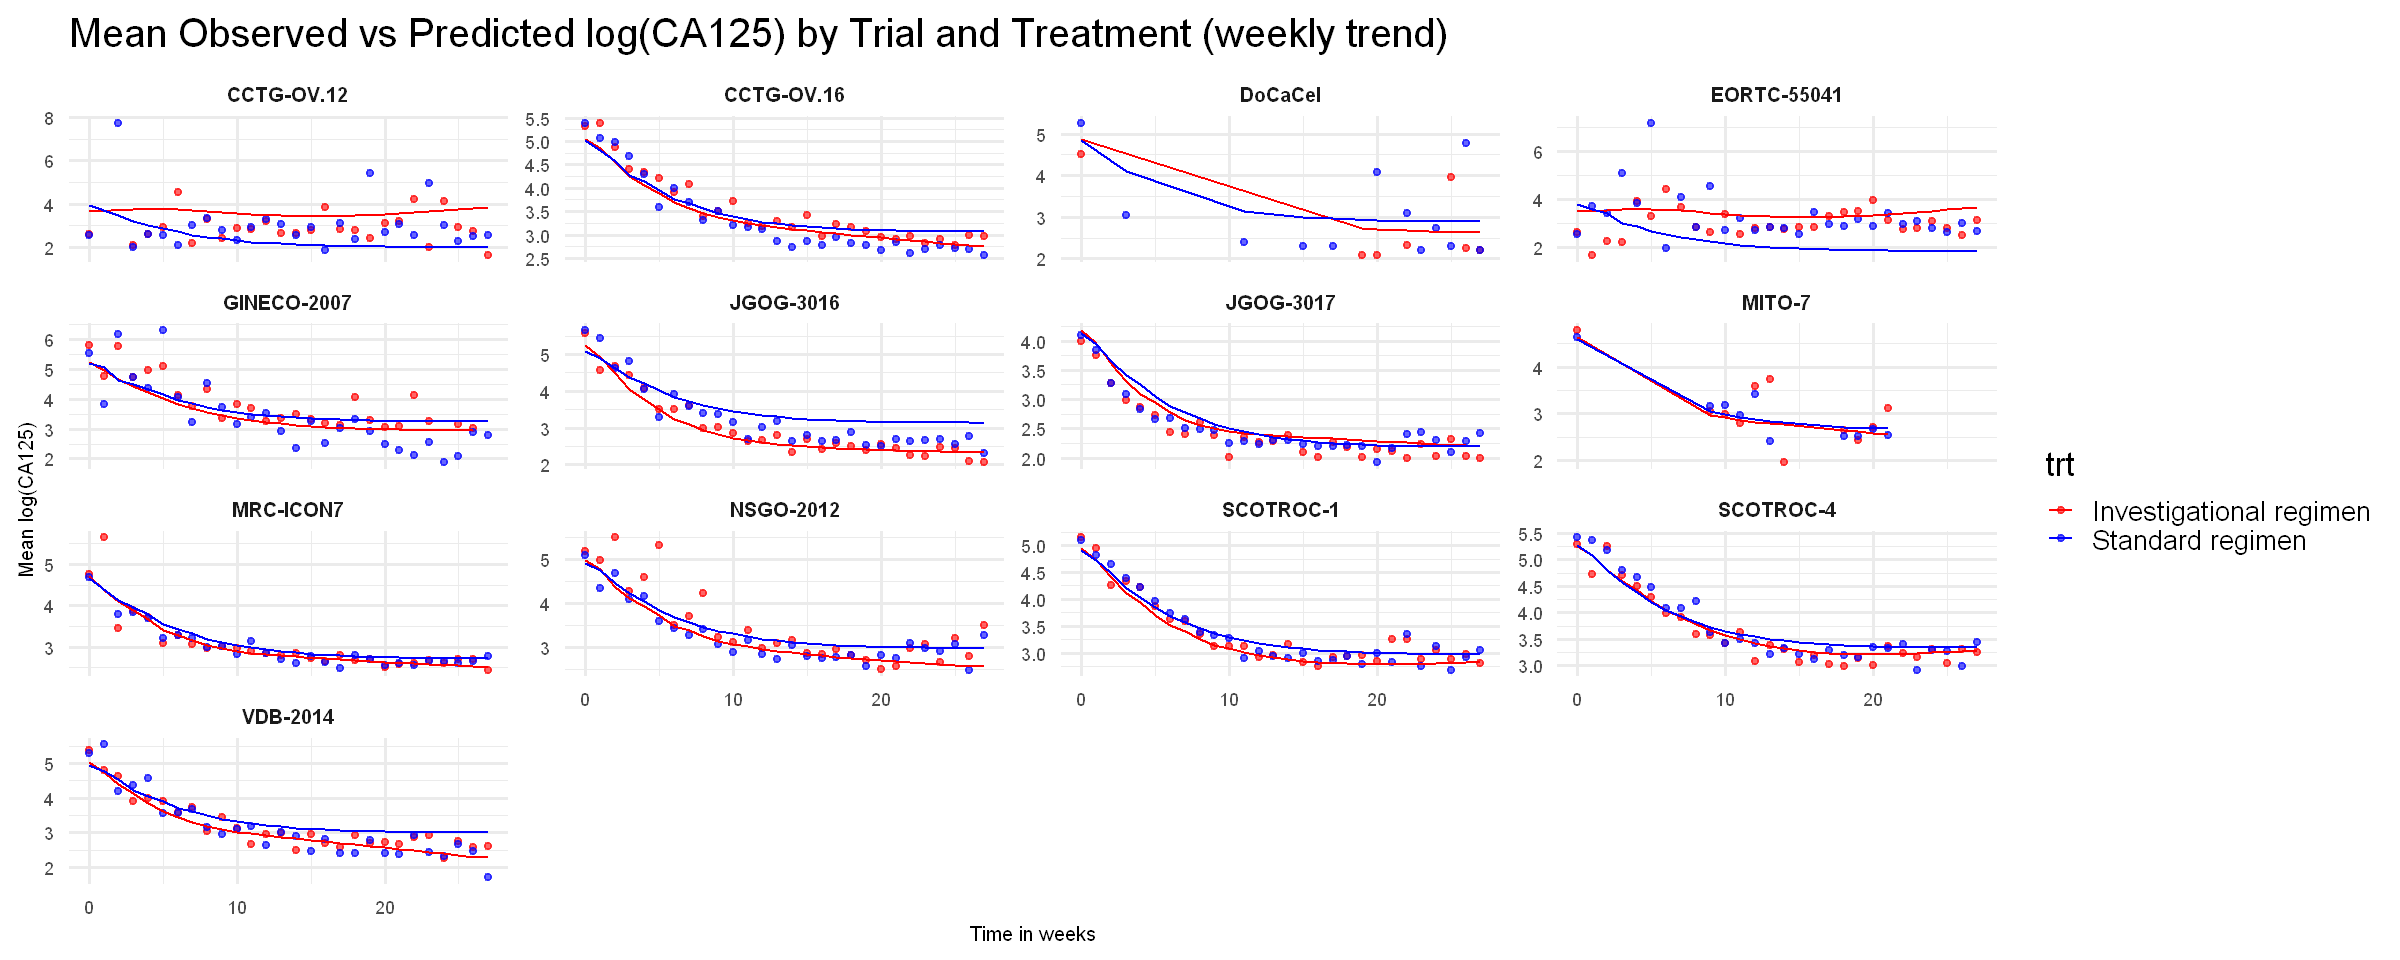

In [ ]:
# Comparison between real trajectories and predicited ones

options(repr.plot.width = 20, repr.plot.height = 8)
ca125_all_6 %>% mutate(week=round(time_ca125/7))%>%mutate(pred_all_13_nullbij= predict(
  ncs_trt_all,
  newdata = ca125_all_6,
  re.form = ~(trt_bin:ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) | trialid)
))%>%
  group_by(trt, trialid, week) %>%
  summarise(
    mean_log_ca125 = mean(log(CA125_mes), na.rm = TRUE),
    mean_pred      = mean(pred_all_13_nullbij, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = mean_log_ca125),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = mean_pred),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment (weekly trend)",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

*Adéquation et tendance*

# Joint modeling

## Model

**Longitudinal model**
$
Y_i(t) = (\beta_0 +b_{0i})+ \sum_{k=1}^{3} (\beta_k+b_{ki}) \, ns_k(t)+ \sum_{k=1}^{3} \gamma_k \, ns_k(t)*T_i+ \varepsilon_i(t)
$

$
b_i \sim \mathcal{N}(0, D), \quad \varepsilon_i(t) \sim \mathcal{N}(0, \sigma^2)
$\
**Survival model**
$
h_i(t) = h_0(t)\exp(\alpha \, T_i)
$

$
h_0(t) = \sum_{m=1}^{M} \lambda_m B_m(t)
$

**Joint association structure**

$
h_i(t \mid b_i) = h_0(t)\exp(\alpha \, T_i + \eta^\top b_i)
$\
**Full likelihood**

$
L = \prod_{i=1}^N 
\int 
f(Y_i \mid b_i)\,
f(T_i, \delta_i \mid b_i)\,
f(b_i)\, db_i
$

In [ ]:
internal_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.22,0.66))
boundary_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.18,0.98))
ns_basis <- ns(ca125_all_6$time_ca125,knots = internal_knots,Boundary.knots = boundary_knots)
ca125_all_6["id_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$id)))
ca125_all_6["trialid_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$trialid)))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [ ]:
jointed_lcmm_pfs<-readRDS("./results/models/jointed_lcmm_pfs.rds")

In [ ]:
summary(jointed_lcmm_pfs)

Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = ca125_all_6)
 
Statistical Model: 
     Dataset: ca125_all_6 
     Number of subjects: 8140 
     Number of observations: 47463 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 5544
        M-splines constant baseline risk function with nodes 
        0 289 508 980 5310.001  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  78 
     Convergence criteria: parameters= 1.3e-09 
                         : likelihood= 7.9e-06 
                         : second derivatives= 4.8e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -90969.66  
     AIC: 1

In [ ]:
first_values <- ca125_all_6 %>% filter(trt_bin==0)%>%
  arrange(id_num, time_ca125) %>%   
  group_by(id_num) %>%
  slice(1) %>%                      # keep first record per patient
  ungroup()

mean(first_values$CA125_mes, na.rm = TRUE)

[1] 574.9648

* CI (Conditional independence) assuptiom (p-value=0) => longitudinal process and progression-time are not independent given random effects => CA125 itself carries additional information about progression, apart from patient-specific characteristics
* No treatment effect on progression-time
* Splines coeffs are significant => The risk of progression and evolution of CA125 vary nonlinearly over time
* High variances => patient-level heterogeneity in baseline CA125 and trajectory shape

In [ ]:
p<-WaldMult(jointed_lcmm_pfs, pos=c(13,14,15))
p

,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,6.57139,0.08689


Non significant treatment effect across all splines

## Predictions

dynpred: “Given what I have observed as CA125 values for this patient up to time t, what is their survival probability going forward?”

# 🔹 Step-by-step mathematical idea behind dynamic prediction

## 1. Joint model specification

We consider a joint model with two linked components:

### Longitudinal model
$
Y_i(t) = X_i(t)\beta + Z_i(t) u_i + \epsilon_i(t)
$

- $ Y_i(t)$:  log CA125
- $ u_i $: subject-specific random effects
- $\epsilon_i(t)$: measurement error

### Survival model
$
\lambda_i(t \mid u_i) = \lambda_0(t)\exp\big(\gamma X_i + \alpha f(u_i, t)\big)
$

- $ \lambda_0(t)$: baseline hazard
- The hazard depends on the subject’s latent trajectory via $ u_i$

## 2. Unknown random effects

The random effects $ u_i $ are not observed.  
Instead, we estimate their posterior distribution using the observed longitudinal data up to time $ s $:

$
p(u_i \mid \text{data up to time } s)
$


## 3. Conditional survival given $ u_i $

If $ u_i $ were known, the survival function is:

$
S_i(t \mid u_i) = \exp\left(-\int_0^t \lambda_i(u \mid u_i)\, du \right)
$

The conditional probability of experiencing the event in the interval \([s, s+t]\) is:

$
P(T_i \le s+t \mid T_i > s, u_i)
= 1 - \frac{S_i(s+t \mid u_i)}{S_i(s \mid u_i)}
$


## 4. Marginal prediction (integrating over $ u_i $)

Since $ u_i $ is unknown, we integrate over its posterior distribution:

$
P(T_i \le s+t \mid \text{data}) =
\int \left[
1 - \frac{S_i(s+t \mid u_i)}{S_i(s \mid u_i)}
\right]
p(u_i \mid \text{data up to } s)\, du_i
$


## 5. Monte Carlo approximation

This integral is approximated numerically:

1. Draw samples:
$
u_i^{(1)}, \dots, u_i^{(M)} \sim p(u_i \mid \text{data})
$

2. Compute for each draw:
$
p^{(m)} = 1 - \frac{S_i(s+t \mid u_i^{(m)})}{S_i(s \mid u_i^{(m)})}
$

3. Summarize:
- Median → predicted probability
- 2.5% and 97.5% → confidence interval


## 6. Interpretation

This gives a **dynamic prediction**:

$
P(T_i \le s+t \mid T_i > s,\ \text{history up to } s)
$

That is, the probability that subject $ i $ experiences the event in the next $ t $ time units, given:
- they are event-free at time $ s $
- their observed biomarker trajectory up to time $ s $

In [ ]:
dynpreds<-readRDS("./results/models/pred_dynpred.rds")

In [ ]:
# Evaluation of prediction of progression at 2, 3 and 5 years
# horizons:
# 550  = ~2 years
# 915  = ~3 years
# 1645 = ~5 years

# function for manual AUC
auc_manual <- function(labels, scores) {
  roc_obj <- pROC::roc(labels, scores, quiet = TRUE)
  as.numeric(pROC::auc(roc_obj))
}

# evaluation for each horizon
eval_df <- map_dfr(
  c(550, 915, 1645),
  function(h) {
    
    # convert horizon to years for observed event definition
    years <- case_when(
      h == 550  ~ 2,
      h == 915  ~ 3,
      h == 1645 ~ 5
    )
    
    obs <- dynpreds[[1]] %>%
      filter(horizon == h) %>%
      select(id_num, pred) %>%
      left_join(
        ca125_all_6 %>%
          select(id_num, pfs_time_d, pfs_statut) %>%
          distinct(),
        by = "id_num"
      ) %>%
      mutate(
        event = ifelse(pfs_time_d <= years * 365 & pfs_statut == 1, 1, 0),
        pred_class = as.numeric(pred >= 0.5)
      )
    
    obs %>%
      summarise(
        years = years,
        
        accuracy =
          mean(pred_class == event, na.rm = TRUE),
        
        sensitivity =
          sum(pred_class == 1 & event == 1, na.rm = TRUE) /
          sum(event == 1, na.rm = TRUE),
        
        specificity =
          sum(pred_class == 0 & event == 0, na.rm = TRUE) /
          sum(event == 0, na.rm = TRUE),
        
        auc =
          auc_manual(event, pred),
        
        n_events =
          sum(event, na.rm = TRUE),
        
        n_patients =
          n()
      )
  }
)

eval_df

years,accuracy,sensitivity,specificity,auc,n_events,n_patients
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2,0.4390554,0.0000000,0.9172821,0.5070629,4548,8140
3,0.6268382,0.8774743,0.0000000,0.5068975,5052,8140
5,0.6638857,0.8798726,0.0000000,0.5108831,5336,8140


*Goodness of fit of joint model*

## Link between risk ratio and CA125

**One joint model per trial**

In [ ]:
results_list <- list()
ca125_all_6<-ca125_all_6 %>%arrange(id_num)
trial_list <- split(ca125_all_6, ca125_all_6$trialid)
for (trial_name in names(trial_list)) {
  
  cat("Fitting trial:", trial_name, "\n")
  
  df <- trial_list[[trial_name]]
  df$pfs_statut <- ifelse(df$pfs_statut %in% c("1", 1),1,0)
  internal_knots <- quantile(df$time_ca125, probs = c(0.22,0.66))
  boundary_knots <- quantile(df$time_ca125, probs = c(0.18,0.98))
  ns_basis <- ns( df$time_ca125, knots = internal_knots, Boundary.knots = boundary_knots ) 
  # Add to dataset 
  colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis)) 
  df <- cbind(df, ns_basis)
  df$trt_ns1 <- df$trt_bin * df$ns1
  df$trt_ns2 <- df$trt_bin * df$ns2
  df$trt_ns3 <- df$trt_bin * df$ns3
  
  res <- tryCatch({
    
    # -------------------------
    # 1. Joint model
    # -------------------------
    model <- Jointlcmm(
      fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + ns2 + ns3),
      random = ~ ns1 + ns2 + ns3,
      subject = "id_num",
      ng = 1,
      survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin,
      hazard = "splines",
      data = df
    )
    # -------------------------
    # 2. Dynamic predictions
    # -------------------------
    newdata_trt1 <- df 
    newdata_trt1$trt_bin <- 1
    newdata_trt0 <- df
    newdata_trt0$trt_bin <- 0
    
    dyn1 <- dynpred(model, newdata_trt1,
                    landmark = 180, horizon = 550,
                    var.time = "time_ca125")
    
    dyn0 <- dynpred(model, newdata_trt0,
                    landmark = 180, horizon = 550,
                    var.time = "time_ca125")
    
    rr_df <- dyn1$pred %>%
      select(id_num, pred) %>%
      rename(pred1 = pred) %>%
      left_join(
        dyn0$pred %>%
          select(id_num, pred) %>%
          rename(pred0 = pred),
        by = "id_num"
      ) %>%
      mutate(
        rr_joint = pred1 / pred0,
        log_rr_joint = log(rr_joint)
      )
    
    # -------------------------
    # 3. CA125 prediction
    # -------------------------
    log_ca125_pred <- predictY(
      model,
      newdata = df,
      var.time = "time_ca125"
    )$pred
    
    ca125_patient <- data.frame(
      id_num = df$id_num,
      log_ca125_pred = as.vector(log_ca125_pred)
    ) %>%
      group_by(id_num) %>%
      summarise(
        log_ca125_pred = mean(log_ca125_pred, na.rm = TRUE),
        .groups = "drop"
      )
    
    rr_df <- rr_df %>%
      left_join(ca125_patient, by = "id_num")
    
    # -------------------------
    # 6. Trial summary
    # -------------------------
    n_events_trial <- sum(df$pfs_statut, na.rm = TRUE)
    trial_summary <- rr_df %>%
      summarise(
        mean_log_rr_joint = mean(log_rr_joint, na.rm = TRUE),
        mean_log_ca125 = mean(log_ca125_pred, na.rm = TRUE),
        .groups = "drop"
      ) %>%
      mutate(
        trialid = trial_name,
        n_events = n_events_trial
      )
    
    
    
  }, error = function(e) {
    cat("❌ Failed:", trial_name, "\n")
    print(e$message)
    NULL
  })
  
  results_list[[trial_name]] <- res
}

trial_summary_all <- bind_rows(results_list)

Fitting trial: CCTG-OV.12 


Warning message in Surv(time = c(783.99999375, 783.99999375, 783.99999375, 376.000525, :
"type= 'mstate' is deprecated, use a factor variable as status"


       id_num landmark horizon      pred
  [1,]      1      180     550 0.6554529
  [2,]      2      180     550 0.6554529
  [3,]      3      180     550 0.6554529
  [4,]      4      180     550 0.6554529
  [5,]      5      180     550        NA
  [6,]      6      180     550 0.6554529
  [7,]      7      180     550 0.6554529
  [8,]      8      180     550 0.6554529
  [9,]      9      180     550        NA
 [10,]     10      180     550 0.6554529
 [11,]     11      180     550 0.6554529
 [12,]     12      180     550        NA
 [13,]     13      180     550        NA
 [14,]     14      180     550        NA
 [15,]     15      180     550 0.6554529
 [16,]     16      180     550 0.6554529
 [17,]     17      180     550 0.6554529
 [18,]     18      180     550 0.6554529
 [19,]     19      180     550 0.6554529
 [20,]     20      180     550        NA
 [21,]     21      180     550 0.6554529
 [22,]     22      180     550        NA
 [23,]     23      180     550 0.6554529
 [24,]     24   

Warning message in Surv(time = c(416.99375, 416.99375, 416.99375, 416.99375, 416.99375, :
"type= 'mstate' is deprecated, use a factor variable as status"


       id_num landmark horizon      pred
  [1,]    195      180     550 0.6088624
  [2,]    196      180     550 0.6088624
  [3,]    197      180     550 0.6088624
  [4,]    198      180     550 0.6088624
  [5,]    199      180     550 0.6088624
  [6,]    200      180     550 0.6088624
  [7,]    201      180     550 0.6088624
  [8,]    202      180     550 0.6088624
  [9,]    203      180     550 0.6088624
 [10,]    204      180     550 0.6088624
 [11,]    205      180     550 0.6088624
 [12,]    206      180     550 0.6088624
 [13,]    207      180     550 0.6088624
 [14,]    208      180     550 0.6088624
 [15,]    209      180     550 0.6088624
 [16,]    210      180     550 0.6088624
 [17,]    211      180     550 0.6088624
 [18,]    212      180     550 0.6088624
 [19,]    213      180     550 0.6088624
 [20,]    214      180     550 0.6088624
 [21,]    215      180     550 0.6088624
 [22,]    216      180     550 0.6088624
 [23,]    217      180     550 0.6088624
 [24,]    218   

...

        id_num landmark horizon      pred
   [1,]   5728      180     550 0.5889589
   [2,]   5729      180     550 0.5889589
   [3,]   5730      180     550 0.5889589
   [4,]   5731      180     550 0.5889589
   [5,]   5732      180     550 0.5889589
   [6,]   5733      180     550 0.5889589
   [7,]   5734      180     550 0.5889589
   [8,]   5735      180     550 0.5889589
   [9,]   5736      180     550 0.5889589
  [10,]   5737      180     550 0.5889589
  [11,]   5738      180     550 0.5889589
  [12,]   5739      180     550 0.5889589
  [13,]   5740      180     550 0.5889589
  [14,]   5741      180     550        NA
  [15,]   5742      180     550 0.5889589
  [16,]   5743      180     550 0.5889589
  [17,]   5744      180     550 0.5889589
  [18,]   5745      180     550 0.5889589
  [19,]   5746      180     550 0.5889589
  [20,]   5747      180     550        NA
  [21,]   5748      180     550 0.5889589
  [22,]   5749      180     550 0.5889589
  [23,]   5750      180     550 0.

Warning message in Surv(time = c(453.000000004562, 453.000000004562, 453.000000004562, :
"type= 'mstate' is deprecated, use a factor variable as status"


       id_num landmark horizon     pred
  [1,]   6778      180     550 0.653457
  [2,]   6779      180     550 0.653457
  [3,]   6780      180     550 0.653457
  [4,]   6781      180     550 0.653457
  [5,]   6782      180     550 0.653457
  [6,]   6783      180     550 0.653457
  [7,]   6784      180     550 0.653457
  [8,]   6785      180     550 0.653457
  [9,]   6786      180     550 0.653457
 [10,]   6787      180     550 0.653457
 [11,]   6788      180     550 0.653457
 [12,]   6789      180     550 0.653457
 [13,]   6790      180     550 0.653457
 [14,]   6791      180     550 0.653457
 [15,]   6792      180     550       NA
 [16,]   6793      180     550 0.653457
 [17,]   6794      180     550 0.653457
 [18,]   6795      180     550 0.653457
 [19,]   6796      180     550 0.653457
 [20,]   6797      180     550 0.653457
 [21,]   6798      180     550 0.653457
 [22,]   6799      180     550 0.653457
 [23,]   6800      180     550 0.653457
 [24,]   6801      180     550       NA


Warning message in Surv(time = c(588.999999986312, 588.999999986312, 588.999999986312, :
"type= 'mstate' is deprecated, use a factor variable as status"


       id_num landmark horizon      pred
  [1,]   7705      180     550 0.5568818
  [2,]   7706      180     550 0.5568818
  [3,]   7707      180     550 0.5568818
  [4,]   7708      180     550        NA
  [5,]   7709      180     550 0.5568818
  [6,]   7710      180     550 0.5568818
  [7,]   7711      180     550 0.5568818
  [8,]   7712      180     550 0.5568818
  [9,]   7713      180     550 0.5568818
 [10,]   7714      180     550 0.5568818
 [11,]   7715      180     550 0.5568818
 [12,]   7716      180     550 0.5568818
 [13,]   7717      180     550 0.5568818
 [14,]   7718      180     550 0.5568818
 [15,]   7719      180     550 0.5568818
 [16,]   7720      180     550 0.5568818
 [17,]   7721      180     550 0.5568818
 [18,]   7722      180     550 0.5568818
 [19,]   7723      180     550 0.5568818
 [20,]   7724      180     550 0.5568818
 [21,]   7725      180     550 0.5568818
 [22,]   7726      180     550 0.5568818
 [23,]   7727      180     550 0.5568818
 [24,]   7728   

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"


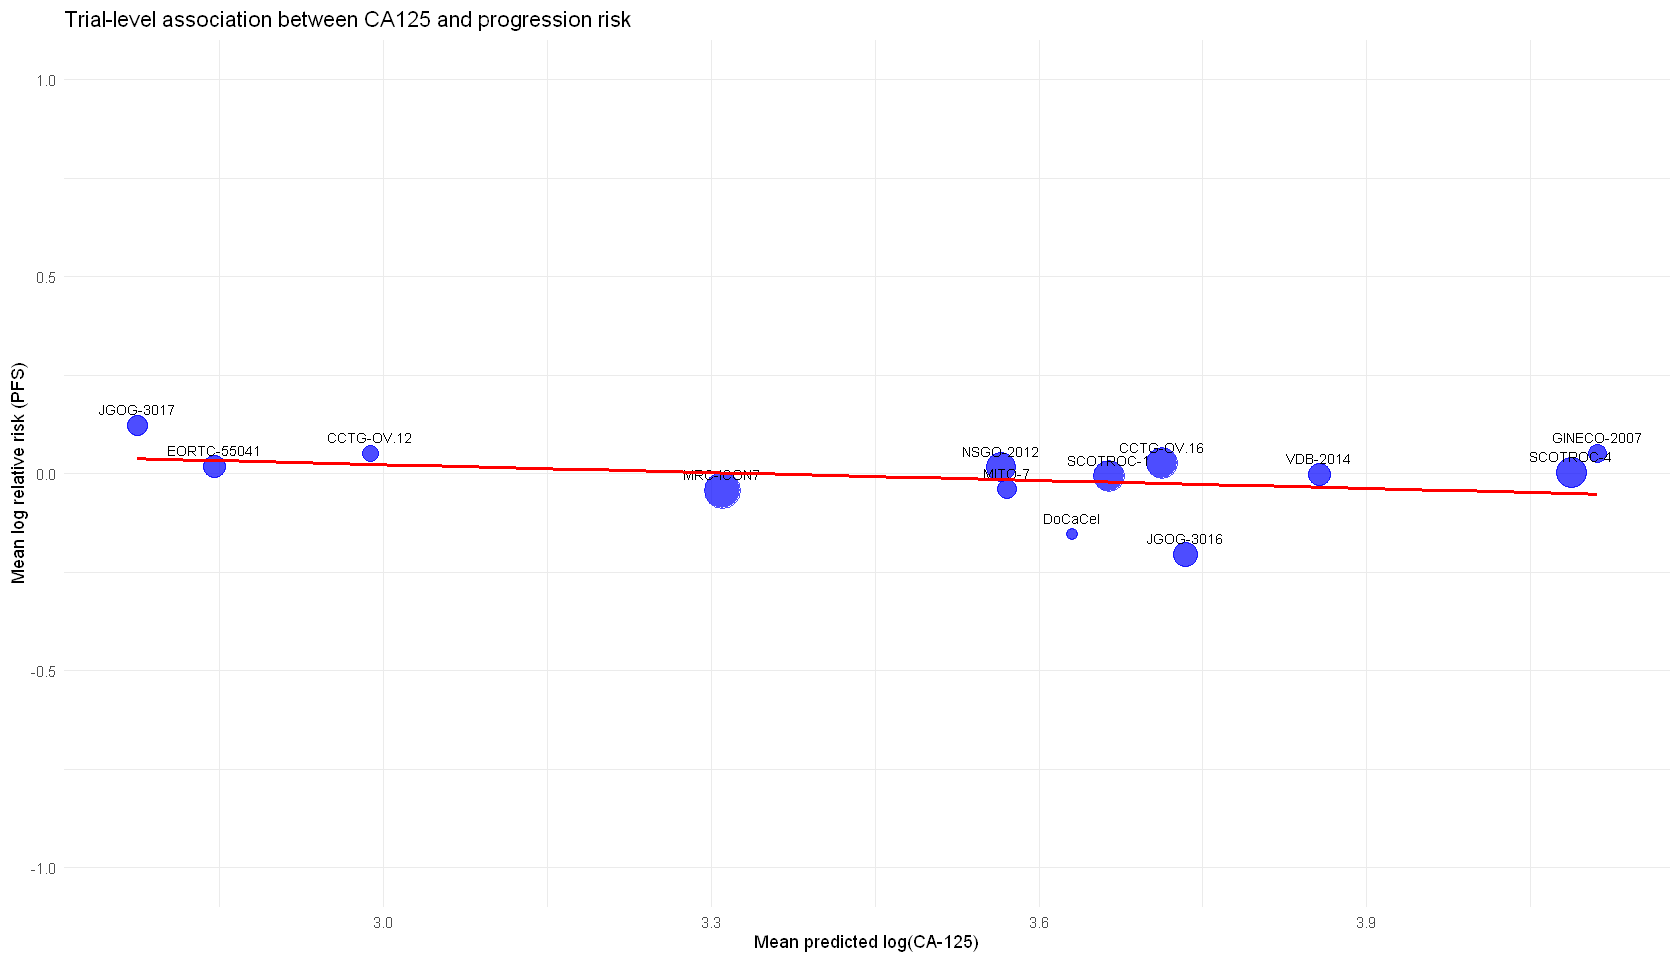

In [ ]:

# =========================
# Plot
# =========================
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(trial_summary_all,
       aes(x = mean_log_ca125,
           y = mean_log_rr_joint,
           size = n_events)) +
  geom_point(color = "blue", alpha = 0.7) +
  geom_text(aes(label = trialid), vjust = -1, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  scale_size(range = c(3, 10)) +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    x = "Mean predicted log(CA-125)",
    y = "Mean log relative risk (PFS)",
    title = "Trial-level association between CA125 and progression risk"
  ) +
  ylim(-1, 1)

In [ ]:
results_list2 <- list()
ca125_all_6<-ca125_all_6 %>%arrange(id_num)
trial_list <- split(ca125_all_6, ca125_all_6$trialid)
for (trial_name in names(trial_list)) {
  
  cat("Fitting trial:", trial_name, "\n")
  
  df <- trial_list[[trial_name]]
  
  # -------------------------
  # Clean survival status
  # -------------------------
  df$pfs_statut <- ifelse(df$pfs_statut %in% c("1", 1),1,0)
  res <- tryCatch({
    
    # -------------------------
    # Natural spline basis
    # -------------------------
    internal_knots <- quantile(df$time_ca125,probs = c(0.22, 0.66),na.rm = TRUE)
    boundary_knots <- quantile(df$time_ca125,probs = c(0.18, 0.98),na.rm = TRUE)
    
    ns_basis <- ns(
      df$time_ca125,
      knots = internal_knots,
      Boundary.knots = boundary_knots
    )
    colnames(ns_basis) <- paste0("ns",1:ncol(ns_basis))
    df <- cbind(df, ns_basis)
    
    # -------------------------
    # Joint model
    # -------------------------
    model <- Jointlcmm(
      
      fixed =
        log_ca125 ~
        ns1 + ns2 + ns3 +
        trt_bin:(ns1 + ns2 + ns3),
      
      random =
        ~ ns1 + ns2 + ns3,
      
      subject = "id_num",
      
      ng = 1,
      
      survival =
        Surv(
          pfs_time_d,
          pfs_statut
        ) ~ trt_bin,
      
      hazard = "splines",
      
      data = df
    )
    
    # -------------------------
    # Extract treatment HR
    # -------------------------
    coef_surv <- model$best["trt_bin"]
    log_hr <- coef_surv[1]
    hr <- exp(log_hr)
    
    # -------------------------
    # Predicted CA125
    # -------------------------
    log_ca125_pred <- predictY(model,newdata = df,var.time = "time_ca125")$pred
    ca125_patient <- data.frame(id_num = df$id_num,log_ca125_pred =as.vector(log_ca125_pred)) %>%
      group_by(id_num) %>%
      summarise(
        log_ca125_pred =
          mean(
            log_ca125_pred,
            na.rm = TRUE
          ),
        .groups = "drop"
      )
    
    # -------------------------
    # Number of events
    # -------------------------
    n_events_trial <- df %>%
      distinct(
        id_num,
        .keep_all = TRUE
      ) %>%
      summarise(
        n_events =
          sum(
            pfs_statut == 1,
            na.rm = TRUE
          )
      ) %>%
      pull(n_events)
    
    # -------------------------
    # Trial summary
    # -------------------------
    trial_summary <- ca125_patient %>%
      summarise(
        mean_log_ca125 =
          mean(
            log_ca125_pred,
            na.rm = TRUE
          ),
        .groups = "drop"
      ) %>%
      mutate(
        trialid = trial_name,
        log_hr = log_hr,
        hr = hr,
        n_events = n_events_trial
      )
    
    trial_summary
    
  }, error = function(e) {
    
    cat(
      "❌ Failed:",
      trial_name,
      "\n"
    )
    
    print(e$message)
    
    NULL
  })
  
  results_list2[[trial_name]] <- res
}

trial_summary_all2 <- bind_rows(results_list2)


Fitting trial: CCTG-OV.12 


Warning message in Surv(time = c(783.99999375, 783.99999375, 783.99999375, 376.000525, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: CCTG-OV.16 


Warning message in Surv(time = c(416.99375, 416.99375, 416.99375, 416.99375, 416.99375, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: DoCaCel 


...

Warning message in Surv(time = c(377.999999986875, 377.999999986875, 377.999999986875, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: SCOTROC-4 


Warning message in Surv(time = c(453.000000004562, 453.000000004562, 453.000000004562, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: VDB-2014 


Warning message in Surv(time = c(588.999999986312, 588.999999986312, 588.999999986312, :
"type= 'mstate' is deprecated, use a factor variable as status"


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"


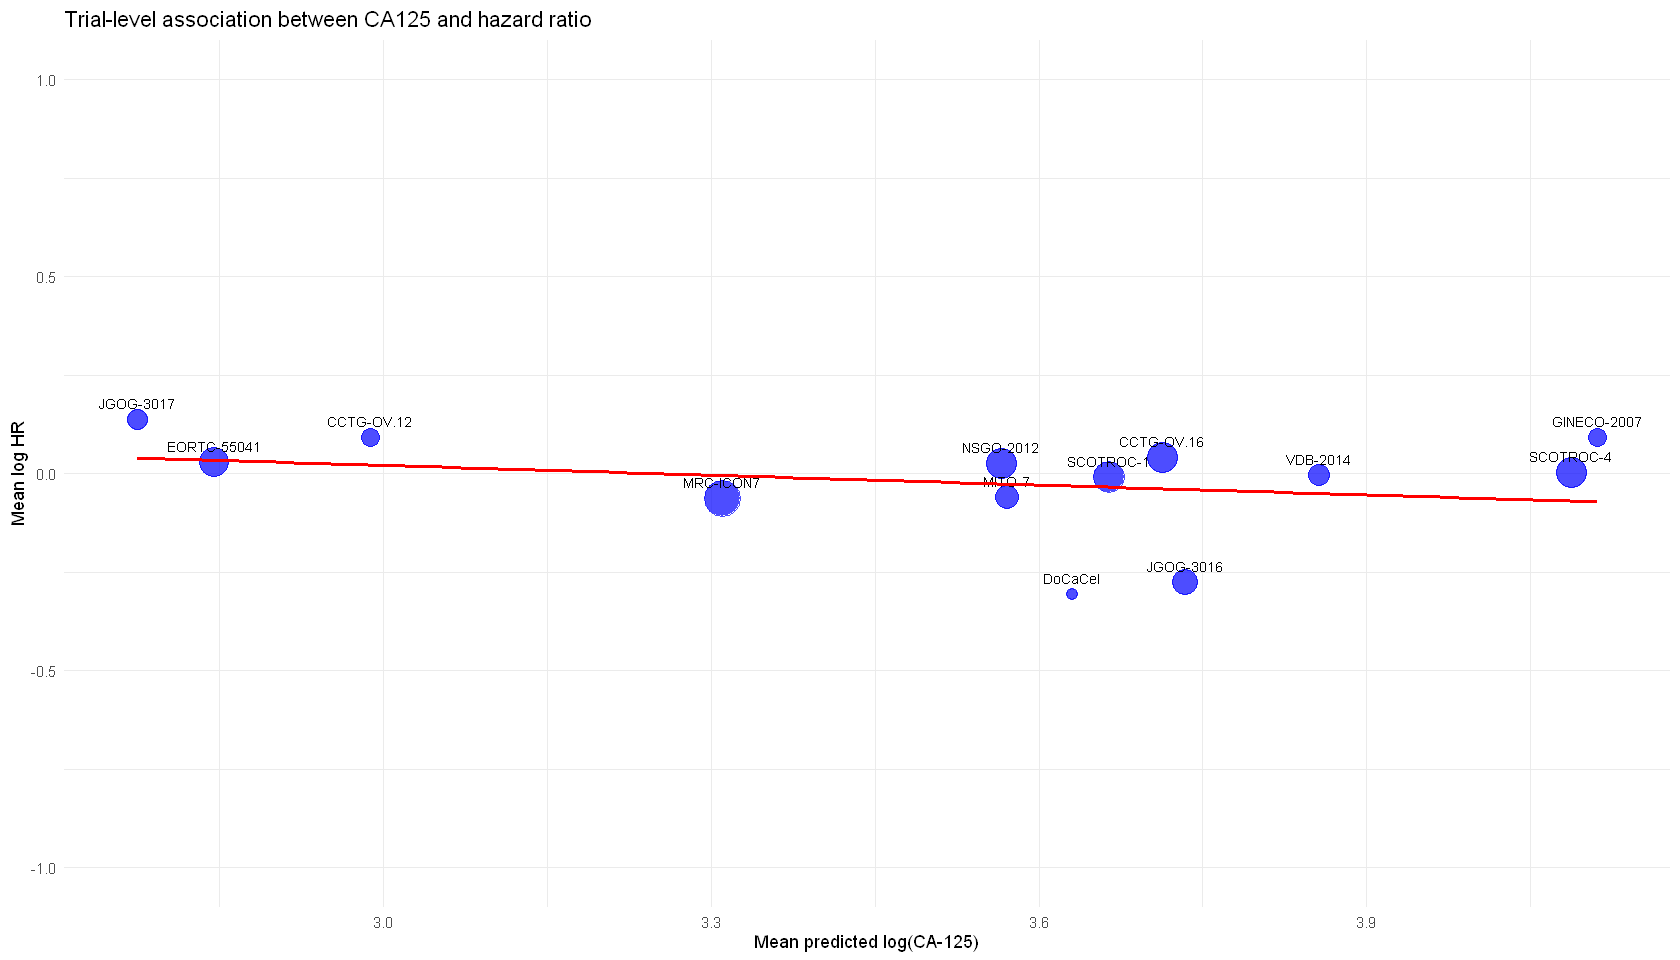

In [ ]:

# =========================
# Plot
# =========================
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(trial_summary_all2,
       aes(x = mean_log_ca125,
           y = log_hr,
           size = n_events)) +
  geom_point(color = "blue", alpha = 0.7) +
  geom_text(aes(label = trialid), vjust = -1, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  scale_size(range = c(3, 10)) +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    x = "Mean predicted log(CA-125)",
    y = "Mean log HR",
    title = "Trial-level association between CA125 and hazard ratio"
  ) +
  ylim(-1, 1)

In [ ]:
#observed vs predicted values weekly trend
results_list3 <- list()
ca125_all_6<-ca125_all_6 %>%arrange(id_num)
trial_list <- split(ca125_all_6, ca125_all_6$trialid)
for (trial_name in names(trial_list)) {
  
  cat("Fitting trial:", trial_name, "\n")
  
  df <- trial_list[[trial_name]]
  
  # -------------------------
  # Clean survival status
  # -------------------------
  df$pfs_statut <- ifelse(df$pfs_statut %in% c("1", 1),1,0)
  df<-df%>% mutate(week=round(time_ca125/7))
  res <- tryCatch({
    
    # -------------------------
    # Natural spline basis
    # -------------------------
    internal_knots <- quantile(df$time_ca125,probs = c(0.22, 0.66),na.rm = TRUE)
    boundary_knots <- quantile(df$time_ca125,probs = c(0.18, 0.98),na.rm = TRUE)
    
    ns_basis <- ns(
      df$time_ca125,
      knots = internal_knots,
      Boundary.knots = boundary_knots
    )
    colnames(ns_basis) <- paste0("ns",1:ncol(ns_basis))
    df <- cbind(df, ns_basis)
    
    # -------------------------
    # Joint model
    # -------------------------
    model <- Jointlcmm(
      
      fixed =
        log_ca125 ~
        ns1 + ns2 + ns3 +
        trt_bin:(ns1 + ns2 + ns3),
      
      random =
        ~ ns1 + ns2 + ns3,
      
      subject = "id_num",
      
      ng = 1,
      
      survival =
        Surv(
          pfs_time_d,
          pfs_statut
        ) ~ trt_bin,
      
      hazard = "splines",
      
      data = df
    )
    
    # -------------------------
    # Predicted CA125
    # -------------------------
    log_ca125_pred <- predictY(model,newdata = df,var.time = "time_ca125")$pred
    ca125_patient <- data.frame(trialid = trial_name, trt=df$trt_bin, log_ca125=as.vector(df$log_ca125), week=df$week, log_ca125_pred =as.vector(log_ca125_pred)) %>%
      group_by(trialid, trt, week) %>%
      summarise(
        log_ca125_pred_week =
          mean(
            log_ca125_pred,
            na.rm = TRUE
          ),
        log_ca125_week =
          mean(
            log_ca125,
            na.rm = TRUE
          ),
        .groups = "drop"
      )
    
  }, error = function(e) {
    
    cat(
      "❌ Failed:",
      trial_name,
      "\n"
    )
    
    print(e$message)
    
    NULL
  })
  
  results_list3[[trial_name]] <- res
}

trial_summary_all3 <- bind_rows(results_list3)
head(trial_summary_all3)


Fitting trial: CCTG-OV.12 


Warning message in Surv(time = c(783.99999375, 783.99999375, 783.99999375, 376.000525, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: CCTG-OV.16 


Warning message in Surv(time = c(416.99375, 416.99375, 416.99375, 416.99375, 416.99375, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: DoCaCel 


...

Fitting trial: SCOTROC-4 


Warning message in Surv(time = c(453.000000004562, 453.000000004562, 453.000000004562, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting trial: VDB-2014 


Warning message in Surv(time = c(588.999999986312, 588.999999986312, 588.999999986312, :
"type= 'mstate' is deprecated, use a factor variable as status"


trialid,trt,week,log_ca125_pred_week,log_ca125_week
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,0,0,2.512381,2.553041
CCTG-OV.12,0,2,2.611084,7.753624
CCTG-OV.12,0,3,2.675945,1.968845
CCTG-OV.12,0,4,2.723284,2.602709
CCTG-OV.12,0,5,2.770932,2.534329
CCTG-OV.12,0,6,2.811147,2.079442


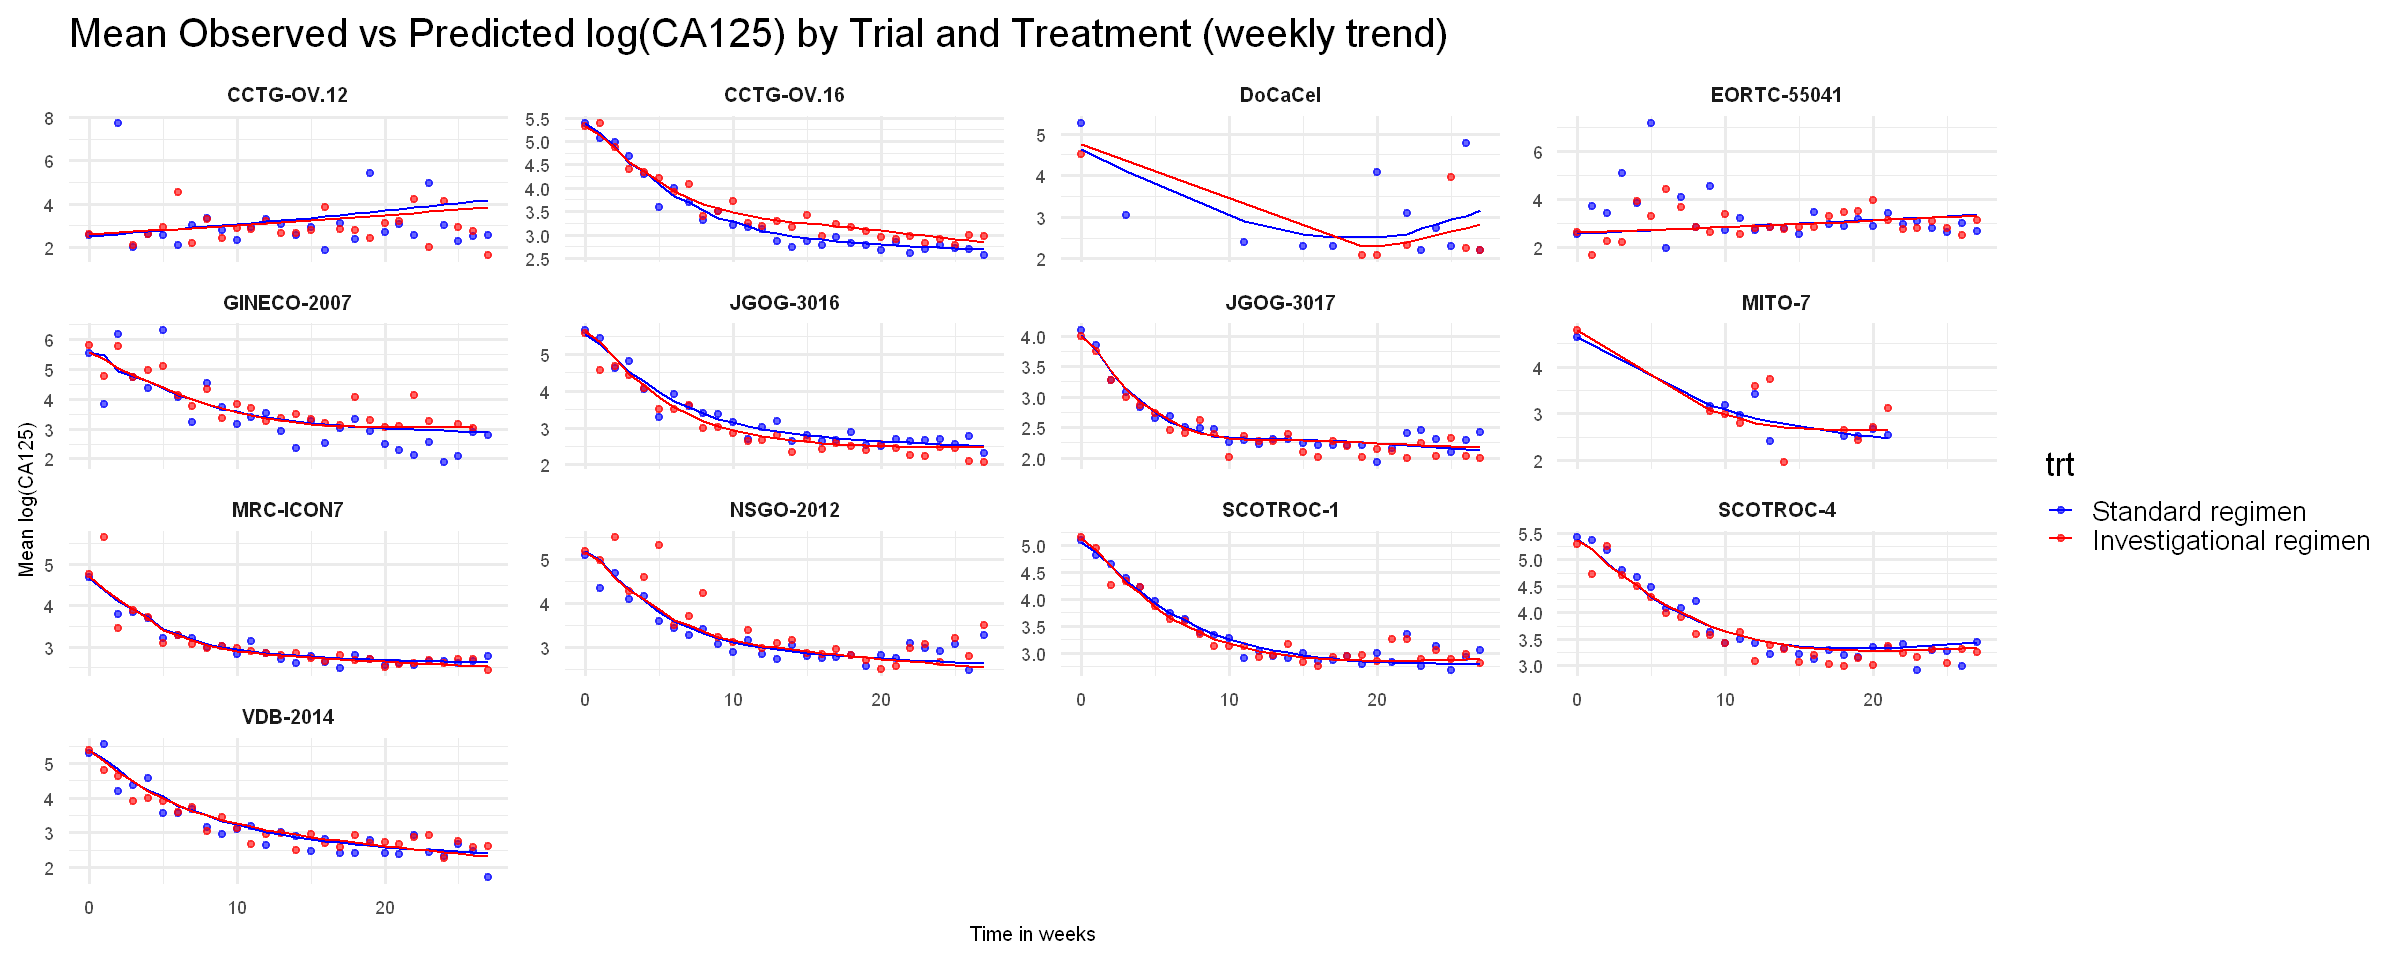

In [ ]:
# Comparison between real trajectories and predicited ones
options(repr.plot.width = 20, repr.plot.height = 8)
trial_summary_all3 %>%
  mutate(trt = factor(trt, levels = c(0, 1),
                        labels = c("Standard regimen", "Investigational regimen")))%>% 
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = log_ca125_week),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = log_ca125_pred_week),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment (weekly trend)",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

**Compute $R^2_{trial}$**
- One joint model by trial then extract log(HR) associated with "trt_bin"
- Predict average log(CA-125) trajectory for treatment group and control group using joint model\
1) **Nadir:** $\Delta = min_t(\hat{Y}_{trt}) - min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta$ 
2) **Time to nadir:** $\Delta_t = \text{time to }min_t(\hat{Y}_{trt}) - \text{time to }min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta_t$
3) **Difference of slopes:** $S_i=\frac{\hat{Y}(t_i) -\hat{Y}(t_i-1)}{t_i - t_i-1}$, $i \in \{30,60,90,120,150,180\}$, $log(HR) = \alpha + \beta (S_{i_{trt}}- S_{i_{ctrl}})$
4) **Area between curves:** $AUC\approx \sum_{i=1}^{n-1} (t_{i+1} - t_i)\,\frac{(\hat{Y_{trt}}(t_i) -\hat{Y_{ctrl}}(t_i) )+ (\hat{Y}_{trt}(t_{i+1}) -\hat{Y}_{ctrl}(t_{i+1}))}{2}$, $log (HR)= \alpha + \beta AUC$
5) **Reduction from baseline:** $R=\frac{\hat{Y}(t_0) - \hat{y}(t_f)}{\hat{Y}(t_0)}$, $\Delta R = R_{trt} - R_{ctrl}$, $log (HR)= \alpha + \beta \Delta R$ (refaire à tous les mois)
6) **Methode henderson:** $logHR= \alpha + \beta T$, T=vecteur effet traitement sur surrogate
7) $log(HR)= \alpha +\beta D_i$,  $D_i=\hat{Y}(t_i)_{trt} - \hat{Y}(t_i)_{ctrl}$, $t_i \in \{60,180\}$




In [ ]:

# -----------------------------
# storage
# -----------------------------

results_list <- list()
model_store <- list()
nadirs<-list()
nadirs_week<-list()
wald_list <-list()

# -----------------------------
# loop
# -----------------------------

for (trial_name in names(trial_list)) {

  cat("Fitting:", trial_name, "\n")

  df <- trial_list[[trial_name]]

  # -------------------------
  # spline basis
  # -------------------------
  internal_knots <- quantile(df$time_ca125, c(0.22, 0.66))
  boundary_knots <- quantile(df$time_ca125, c(0.18, 0.98))

  ns_basis <- ns(df$time_ca125,
                 knots = internal_knots,
                 Boundary.knots = boundary_knots)

  colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis))
  df <- cbind(df, ns_basis)

  # -------------------------
  # model
  # -------------------------
  model <- tryCatch({

    Jointlcmm(
      fixed = log_ca125 ~ ns1 + ns2 + ns3 +
        trt_bin:(ns1 + ns2 + ns3),
      random = ~ ns1 + ns2 + ns3,
      subject = "id_num",
      ng = 1,
      survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin,
      hazard = "splines",
      data = df,
      maxiter = 1500
    )
  
  }, error = function(e) NULL)

  if (is.null(model)) next
  model_store[[trial_name]] <- model
  model_coefs<-model$best
  wald_list[[trial_name]] <-WaldMult(model, pos=c(13,14,15))
  beta_longitudinal_trt = model_coefs[grep("ns[1-3]:trt_bin", names(model_coefs))]

  # -------------------------
  # prediction grid
  # -------------------------
  time_grid <- seq(min(df$time_ca125),
                   max(df$time_ca125),
                   length.out = 200)

  pred_ctrl <- data.frame(time_ca125 = time_grid, trt_bin = 0)
  pred_trt  <- data.frame(time_ca125 = time_grid, trt_bin = 1)

  ns_ctrl <- predict(ns(df$time_ca125,
                        knots = internal_knots,
                        Boundary.knots = boundary_knots),
                     newx = time_grid)

  colnames(ns_ctrl) <- c("ns1","ns2","ns3")

  pred_ctrl <- cbind(pred_ctrl, ns_ctrl)
  pred_trt  <- cbind(pred_trt, ns_ctrl)

  # -------------------------
  # predictions
  # -------------------------
  y_ctrl <- predictY(model, newdata = pred_ctrl, var.time = "time_ca125")
  y_trt  <- predictY(model, newdata = pred_trt,  var.time = "time_ca125")

  # -------------------------
  # NADIR
  # -------------------------
  nadir_ctrl <- min(y_ctrl$pred[,1], na.rm=TRUE)
  nadir_trt  <- min(y_trt$pred[,1], na.rm=TRUE)
  delta_nadir <- nadir_trt - nadir_ctrl
  nadirs[[trial_name]]<-data.frame(nadir_trt=nadir_trt,nadir_ctrl=nadir_ctrl)

  # -------------------------
  # weekly NADIR
  # -------------------------
  weekly_ctrl <- get_weekly_nadir(time_grid, y_ctrl$pred, week_size = 7)
  weekly_trt  <- get_weekly_nadir(time_grid, y_trt$pred,  week_size = 7)

  # global nadir (from weekly values)

  nadirs_week[[trial_name]] <- data.frame(
    nadir_trt = min(weekly_trt$x, na.rm = TRUE),
    nadir_ctrl = min(weekly_ctrl$x, na.rm = TRUE)
  )
  # -------------------------
  # time-to-nadir
  # -------------------------
  t_nadir_ctrl <- time_grid[which.min(y_ctrl$pred[,1])]
  t_nadir_trt  <- time_grid[which.min(y_trt$pred[,1])]
  delta_t_nadir <- t_nadir_trt - t_nadir_ctrl

  # -------------------------
  # AUC
  # -------------------------
  auc_ctrl <- compute_auc(y_ctrl, time_grid)
  auc_trt  <- compute_auc(y_trt, time_grid)
  delta_auc <- auc_trt - auc_ctrl

  # -------------------------
  # percent reduction
  # -------------------------
  delta_pcts <- get_monthly_pct_reduction(
  time_grid,
  y_ctrl,
  y_trt,
  months = 1:6)

  # -------------------------
  # 6-month slopes
  # -------------------------
  delta_slopes <- get_monthly_slopes(time_grid, y_ctrl, y_trt)

  # -------------------------
  # Absolute differences
  # -------------------------

  #1 month
  idx_30  <- which.min(abs(time_grid - 30))
  D_30 <- y_trt$pred[idx_30, 1] - y_ctrl$pred[idx_30, 1]
  #2 months
  idx_60  <- which.min(abs(time_grid - 60))
  D_60 <- y_trt$pred[idx_60, 1] - y_ctrl$pred[idx_60, 1]
  #3 months
  idx_90  <- which.min(abs(time_grid - 90))
  D_90 <- y_trt$pred[idx_90, 1] - y_ctrl$pred[idx_90, 1]
  #4 months
  idx_120  <- which.min(abs(time_grid - 120))
  D_120 <- y_trt$pred[idx_120, 1] - y_ctrl$pred[idx_120, 1]
  #5 months
  idx_150  <- which.min(abs(time_grid - 150))
  D_150 <- y_trt$pred[idx_150, 1] - y_ctrl$pred[idx_150, 1]
  #6 months
  idx_180 <- which.min(abs(time_grid - 180))
  D_180 <- y_trt$pred[idx_180, 1] - y_ctrl$pred[idx_180, 1]


  # -------------------------
  # store
  # -------------------------
  results_list[[trial_name]] <- data.frame(
    trialid = trial_name,
    logHR = model_coefs["trt_bin"] ,
    SE_logHR = sqrt(diag(vcov(model)))["trt_bin"],
    effect_trt_ca1251 = beta_longitudinal_trt[1],
    effect_trt_ca1252 = beta_longitudinal_trt[2],
    effect_trt_ca1253 = beta_longitudinal_trt[3],

    delta_nadir = delta_nadir,
    delta_time_nadir = delta_t_nadir,
    delta_auc = delta_auc,
    
    pct_m1 = delta_pcts[1],
    pct_m2 = delta_pcts[2],
    pct_m3 = delta_pcts[3],
    pct_m4 = delta_pcts[4],
    pct_m5 = delta_pcts[5],
    pct_m6 = delta_pcts[6],

    absolutediff_m1=D_30,
    absolutediff_m2=D_60,
    absolutediff_m3=D_90,
    absolutediff_m4=D_120,
    absolutediff_m6=D_150,
    absolutediff_m5=D_180,

    slope_m1 = delta_slopes[1],
    slope_m2 = delta_slopes[2],
    slope_m3 = delta_slopes[3],
    slope_m4 = delta_slopes[4],
    slope_m5 = delta_slopes[5],
    slope_m6 = delta_slopes[6],

    n = nrow(df)
  )
}

trial_results <- bind_rows(results_list)

Fitting: CCTG-OV.12 


Warning message in Surv(time = c(783.99999375, 783.99999375, 783.99999375, 376.000525, :
"type= 'mstate' is deprecated, use a factor variable as status"


Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = df, maxiter = 1500)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 194 
     Number of observations: 648 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 88
        M-splines constant baseline risk function with nodes 
        0 152.9994 246.4996 350.9992 784  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  1500 
     Convergence criteria: parameters= 7.1e-12 
                         : likelihood= 1.2e-09 
                         : second derivatives= 1 
 
Goodness-of-fit statistics: 
     maximum log-likelihood:

Warning message in Surv(time = c(416.99375, 416.99375, 416.99375, 416.99375, 416.99375, :
"type= 'mstate' is deprecated, use a factor variable as status"


Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = df, maxiter = 1500)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 731 
     Number of observations: 5517 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 107
        M-splines constant baseline risk function with nodes 
        0 316.5043 483.9867 1034.008 3947.014  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  160 
     Convergence criteria: parameters= 1.4e-08 
                         : likelihood= 1.2e-05 
                         : second derivatives= 6.9e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -5614.17  
 

...

Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = df, maxiter = 1500)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 1050 
     Number of observations: 7779 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 385
        M-splines constant baseline risk function with nodes 
        0 264.75 455 636.75 1253  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  73 
     Convergence criteria: parameters= 6.6e-09 
                         : likelihood= 3.1e-05 
                         : second derivatives= 9.6e-05 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -9520.53  
     AIC: 1909

Warning message in Surv(time = c(453.000000004562, 453.000000004562, 453.000000004562, :
"type= 'mstate' is deprecated, use a factor variable as status"


Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = df, maxiter = 1500)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 927 
     Number of observations: 6262 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 267
        M-splines constant baseline risk function with nodes 
        0 234 343 609 1975  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  16 
     Convergence criteria: parameters= 6.7e-08 
                         : likelihood= 4.5e-05 
                         : second derivatives= 2.1e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -8200.97  
     AIC: 16453.95  


Warning message in Surv(time = c(588.999999986312, 588.999999986312, 588.999999986312, :
"type= 'mstate' is deprecated, use a factor variable as status"


Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = df, maxiter = 1500)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 229 
     Number of observations: 1593 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 35
        M-splines constant baseline risk function with nodes 
        0 346 539 1112 5310.001  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  12 
     Convergence criteria: parameters= 8e-07 
                         : likelihood= 1.5e-05 
                         : second derivatives= 1e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1949.19  
     AIC: 3950.37  
 

In [ ]:
wald_list

,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,0.02806,0.99876
,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,27.02222,1e-05
,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,0,1
,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,0.00015,1
,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,0.74702,0.86209
,Wald Test,p_value


In [ ]:
summary_models <- list(
  nadir = lm(logHR ~ delta_nadir, data = trial_results, weights = n),
  time_nadir = lm(logHR ~ delta_time_nadir, data = trial_results, weights = n),
  auc = lm(logHR ~ delta_auc, data = trial_results, weights = n),
  pct1 = lm(logHR ~ pct_m1, data = trial_results, weights = n),
  pct2= lm(logHR ~ pct_m2, data = trial_results, weights = n),
  pct3= lm(logHR ~ pct_m3, data = trial_results, weights = n),
  pct4= lm(logHR ~ pct_m4, data = trial_results, weights = n),
  pct5= lm(logHR ~ pct_m5, data = trial_results, weights = n),
  pct6= lm(logHR ~ pct_m6, data = trial_results, weights = n),
  henderson = lm(logHR ~ effect_trt_ca1251 + effect_trt_ca1252 + effect_trt_ca1253,data = trial_results, weights = n),
  slope1= lm(logHR ~ slope_m1 ,data = trial_results, weights = n),
  slope2= lm(logHR ~ slope_m2 ,data = trial_results, weights = n),
  slope3= lm(logHR ~ slope_m3 ,data = trial_results, weights = n),
  slope4= lm(logHR ~ slope_m4 ,data = trial_results, weights = n),
  slope5= lm(logHR ~ slope_m5 ,data = trial_results, weights = n),
  slope6= lm(logHR ~ slope_m6 ,data = trial_results, weights = n),
  abs1= lm(logHR ~ absolutediff_m1 ,data = trial_results, weights = n),
  abs2= lm(logHR ~ absolutediff_m2 ,data = trial_results, weights = n),
  abs3= lm(logHR ~ absolutediff_m3 ,data = trial_results, weights = n),
  abs4= lm(logHR ~ absolutediff_m4 ,data = trial_results, weights = n),
  abs5= lm(logHR ~ absolutediff_m5 ,data = trial_results, weights = n),
  abs6= lm(logHR ~ absolutediff_m6 ,data = trial_results, weights = n))

# -----------------------------
# extract R2 table
# -----------------------------
r2_table <- data.frame(
  model = names(summary_models),

  R2 = sapply(summary_models, function(m) summary(m)$r.squared),

  coeff = I(lapply(summary_models, function(m) {
    summary(m)$coefficients[, "Estimate"]
  })),

  pval = I(lapply(summary_models, function(m) {
    summary(m)$coefficients[, "Pr(>|t|)"]
  }))
)

,model,R2,coeff,pval
,<chr>,<dbl>,<I<named list>>,<I<named list>>
nadir,nadir,0.002134825,-0.01851....,0.658941....
time_nadir,time_nadir,0.056423943,-0.00667....,0.877429....
auc,auc,0.125156069,-0.01872....,0.633822....
pct1,pct1,0.008731637,-0.01301....,0.774188....
pct2,pct2,0.079307563,-0.00772....,0.853041....
pct3,pct3,0.177548620,-0.01149....,0.763863....
pct4,pct4,0.180233501,-0.01513....,0.690913....
pct5,pct5,0.091470644,-0.01462....,0.715587....
pct6,pct6,0.016499215,-0.01481....,0.727179....


In [ ]:
#Weigthing by 1/var:
summary_models2 <- list(
  nadir = lm(logHR ~ delta_nadir, data = trial_results, weights = 1/(SE_logHR**2)),
  time_nadir = lm(logHR ~ delta_time_nadir, data = trial_results, weights = 1/(SE_logHR**2)),
  auc = lm(logHR ~ delta_auc, data = trial_results, weights = 1/(SE_logHR**2)),
  pct1 = lm(logHR ~ pct_m1, data = trial_results, weights = 1/(SE_logHR**2)),
  pct2= lm(logHR ~ pct_m2, data = trial_results, weights = 1/(SE_logHR**2)),
  pct3= lm(logHR ~ pct_m3, data = trial_results, weights = 1/(SE_logHR**2)),
  pct4= lm(logHR ~ pct_m4, data = trial_results, weights = 1/(SE_logHR**2)),
  pct5= lm(logHR ~ pct_m5, data = trial_results, weights = 1/(SE_logHR**2)),
  pct6= lm(logHR ~ pct_m6, data = trial_results, weights = 1/(SE_logHR**2)),
  henderson = lm(logHR ~ effect_trt_ca1251 + effect_trt_ca1252 + effect_trt_ca1253,data = trial_results, weights = 1/(SE_logHR**2)),
  slope1= lm(logHR ~ slope_m1 ,data = trial_results, weights = 1/(SE_logHR**2)),
  slope2= lm(logHR ~ slope_m2 ,data = trial_results, weights = 1/(SE_logHR**2)),
  slope3= lm(logHR ~ slope_m3 ,data = trial_results, weights = 1/(SE_logHR**2)),
  slope4= lm(logHR ~ slope_m4 ,data = trial_results, weights = 1/(SE_logHR**2)),
  slope5= lm(logHR ~ slope_m5 ,data = trial_results, weights = 1/(SE_logHR**2)),
  slope6= lm(logHR ~ slope_m6 ,data = trial_results, weights = 1/(SE_logHR**2)),
  abs1= lm(logHR ~ absolutediff_m1 ,data = trial_results, weights = 1/(SE_logHR**2)),
  abs2= lm(logHR ~ absolutediff_m2 ,data = trial_results, weights = 1/(SE_logHR**2)),
  abs3= lm(logHR ~ absolutediff_m3 ,data = trial_results, weights = 1/(SE_logHR**2)),
  abs4= lm(logHR ~ absolutediff_m4 ,data = trial_results, weights = 1/(SE_logHR**2)),
  abs5= lm(logHR ~ absolutediff_m5 ,data = trial_results, weights = 1/(SE_logHR**2)),
  abs6= lm(logHR ~ absolutediff_m6 ,data = trial_results, weights = 1/(SE_logHR**2)))

# -----------------------------
# extract R2 table
# -----------------------------
r2_table2 <- data.frame(
  model = names(summary_models2),

  R2_var = sapply(summary_models2, function(m) summary(m)$r.squared),

  coeff = I(lapply(summary_models2, function(m) {
    summary(m)$coefficients[, "Estimate"]
  })),

  pval = I(lapply(summary_models2, function(m) {
    summary(m)$coefficients[, "Pr(>|t|)"]
  }))
)

,model,R2_var,coeff,pval
,<chr>,<dbl>,<I<named list>>,<I<named list>>
nadir,nadir,9.547766e-03,-0.02300....,0.416963....
time_nadir,time_nadir,3.509850e-02,-0.01510....,0.609432....
auc,auc,4.608381e-02,-0.01747....,0.533754....
pct1,pct1,2.139949e-02,-0.02875....,0.363902....
pct2,pct2,5.466302e-04,-0.02088....,0.496864....
pct3,pct3,4.282469e-02,-0.01590....,0.579952....
pct4,pct4,7.125839e-02,-0.01595....,0.565885....
pct5,pct5,3.033261e-02,-0.01799....,0.526905....
pct6,pct6,2.839114e-03,-0.02305....,0.427766....


In [ ]:
cbind(r2_table[c("model","R2")],r2_table2["R2_var"])

,model,R2,R2_var
,<chr>,<dbl>,<dbl>
nadir,nadir,0.002134825,9.547766e-03
time_nadir,time_nadir,0.056423943,3.509850e-02
auc,auc,0.125156069,4.608381e-02
pct1,pct1,0.008731637,2.139949e-02
pct2,pct2,0.079307563,5.466302e-04
pct3,pct3,0.177548620,4.282469e-02
pct4,pct4,0.180233501,7.125839e-02
pct5,pct5,0.091470644,3.033261e-02
pct6,pct6,0.016499215,2.839114e-03


In [ ]:
#Boostrap for r2 CI
set.seed(123)

B <- 2000
n <- nrow(trial_results)

boot_r2 <- matrix(NA, nrow = B, ncol = 21)
colnames(boot_r2) <- c("nadir","time_nadir","auc","pct1","pct2","pct3", "pct4", "pct5","pct6",
                       "slope1","slope2","slope3","slope4", "slope5","slope6",
                       "abs1","abs2","abs3","abs4","abs5","abs6")

for (b in 1:B) {

  idx <- sample(1:n, size = n, replace = TRUE)
  data_b <- trial_results[idx, ]

  boot_r2[b, ] <- get_r2_models(data_b)
}
boot_summary <- data.frame(
  model = colnames(boot_r2),

  R2 = apply(boot_r2, 2, mean, na.rm = TRUE),

  R2_low = apply(boot_r2, 2, quantile, 0.025, na.rm = TRUE),

  R2_high = apply(boot_r2, 2, quantile, 0.975, na.rm = TRUE)
)

boot_summary

,model,R2,R2_low,R2_high
,<chr>,<dbl>,<dbl>,<dbl>
nadir,nadir,0.20680077,2.823500e-04,0.7383704
time_nadir,time_nadir,0.12296680,4.026611e-07,0.6121502
auc,auc,0.28617924,2.298073e-03,0.8750095
pct1,pct1,0.17523634,2.580528e-04,0.7621400
pct2,pct2,0.18038356,2.096748e-04,0.7024779
pct3,pct3,0.22562677,1.143267e-03,0.7650049
pct4,pct4,0.27810961,6.889699e-03,0.8279796
pct5,pct5,0.31164796,1.287087e-03,0.8365905
pct6,pct6,0.24082176,1.681898e-04,0.7945823


In [ ]:
ca125_all_6 %>%mutate(week_ca125=round(time_ca125/7))%>%
  group_by(trialid, trt, week_ca125) %>%
  summarise(mean_ca125 = mean(log_ca125, na.rm = TRUE), .groups = "drop") %>%
  group_by(trialid, trt) %>%
  summarise(min_mean_ca125 = min(mean_ca125, na.rm = TRUE))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by trialid and trt.
ℹ Output is grouped by trialid.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(trialid, trt))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


trialid,trt,min_mean_ca125
<chr>,<chr>,<dbl>
CCTG-OV.12,Investigational regimen,1.609438
CCTG-OV.12,Standard regimen,1.844461
CCTG-OV.16,Investigational regimen,2.769822
CCTG-OV.16,Standard regimen,2.560898
DoCaCel,Investigational regimen,2.079442
DoCaCel,Standard regimen,2.197225
EORTC-55041,Investigational regimen,1.666102
EORTC-55041,Standard regimen,1.962035
GINECO-2007,Investigational regimen,3.003475


In [ ]:
bind_rows(nadirs_week)

nadir_trt,nadir_ctrl
<dbl>,<dbl>
2.599490,2.512384
2.840088,2.689550
2.122120,2.452159
2.613962,2.573492
3.063969,2.883312
2.456991,2.503884
2.162278,2.123354
2.630669,2.463167
2.523464,2.619287


Leave-one-trial-out

In [ ]:
# ----------------------------------
# formulas for all summary models
# ----------------------------------

summary_formulas <- list(
  nadir = logHR ~ delta_nadir,
  time_nadir = logHR ~ delta_time_nadir,
  auc = logHR ~ delta_auc,

  pct1 = logHR ~ pct_m1,
  pct2 = logHR ~ pct_m2,
  pct3 = logHR ~ pct_m3,
  pct4 = logHR ~ pct_m4,
  pct5 = logHR ~ pct_m5,
  pct6 = logHR ~ pct_m6,

  henderson = logHR ~ effect_trt_ca1251 +
                      effect_trt_ca1252 +
                      effect_trt_ca1253,

  slope1 = logHR ~ slope_m1,
  slope2 = logHR ~ slope_m2,
  slope3 = logHR ~ slope_m3,
  slope4 = logHR ~ slope_m4,
  slope5 = logHR ~ slope_m5,
  slope6 = logHR ~ slope_m6,

  abs1 = logHR ~ absolutediff_m1,
  abs2 = logHR ~ absolutediff_m2,
  abs3 = logHR ~ absolutediff_m3,
  abs4 = logHR ~ absolutediff_m4,
  abs5 = logHR ~ absolutediff_m5,
  abs6 = logHR ~ absolutediff_m6
)

# ----------------------------------
# leave-one-study-out
# ----------------------------------

B <- 1000

loso_boot_results <- list()

for(trial_out in unique(trial_results$trialid)) {

  cat("Leaving out:", trial_out, "\n")

  df_loso <- subset(
    trial_results,
    trialid != trial_out
  )

  model_results <- lapply(names(summary_formulas), function(model_name){

    r2_boot <- replicate(B, {

      idx <- sample(
        seq_len(nrow(df_loso)),
        size = nrow(df_loso),
        replace = TRUE
      )

      boot_df <- df_loso[idx, ]

      fit <- lm(
        summary_formulas[[model_name]],
        data = boot_df,
        weights = n
      )

      summary(fit)$r.squared
    })

    data.frame(
      left_out_trial = trial_out,
      summary = model_name,
      R2 = mean(r2_boot),
      CI_low = quantile(r2_boot, 0.025),
      CI_high = quantile(r2_boot, 0.975)
    )
  })

  loso_boot_results[[trial_out]] <- bind_rows(model_results)
}

loso_boot_r2 <- bind_rows(loso_boot_results)

Leaving out: CCTG-OV.12 
Leaving out: CCTG-OV.16 
Leaving out: DoCaCel 
Leaving out: EORTC-55041 
Leaving out: GINECO-2007 
Leaving out: JGOG-3016 
Leaving out: JGOG-3017 
Leaving out: MITO-7 
Leaving out: MRC-ICON7 
Leaving out: NSGO-2012 
Leaving out: SCOTROC-1 
Leaving out: SCOTROC-4 
Leaving out: VDB-2014 


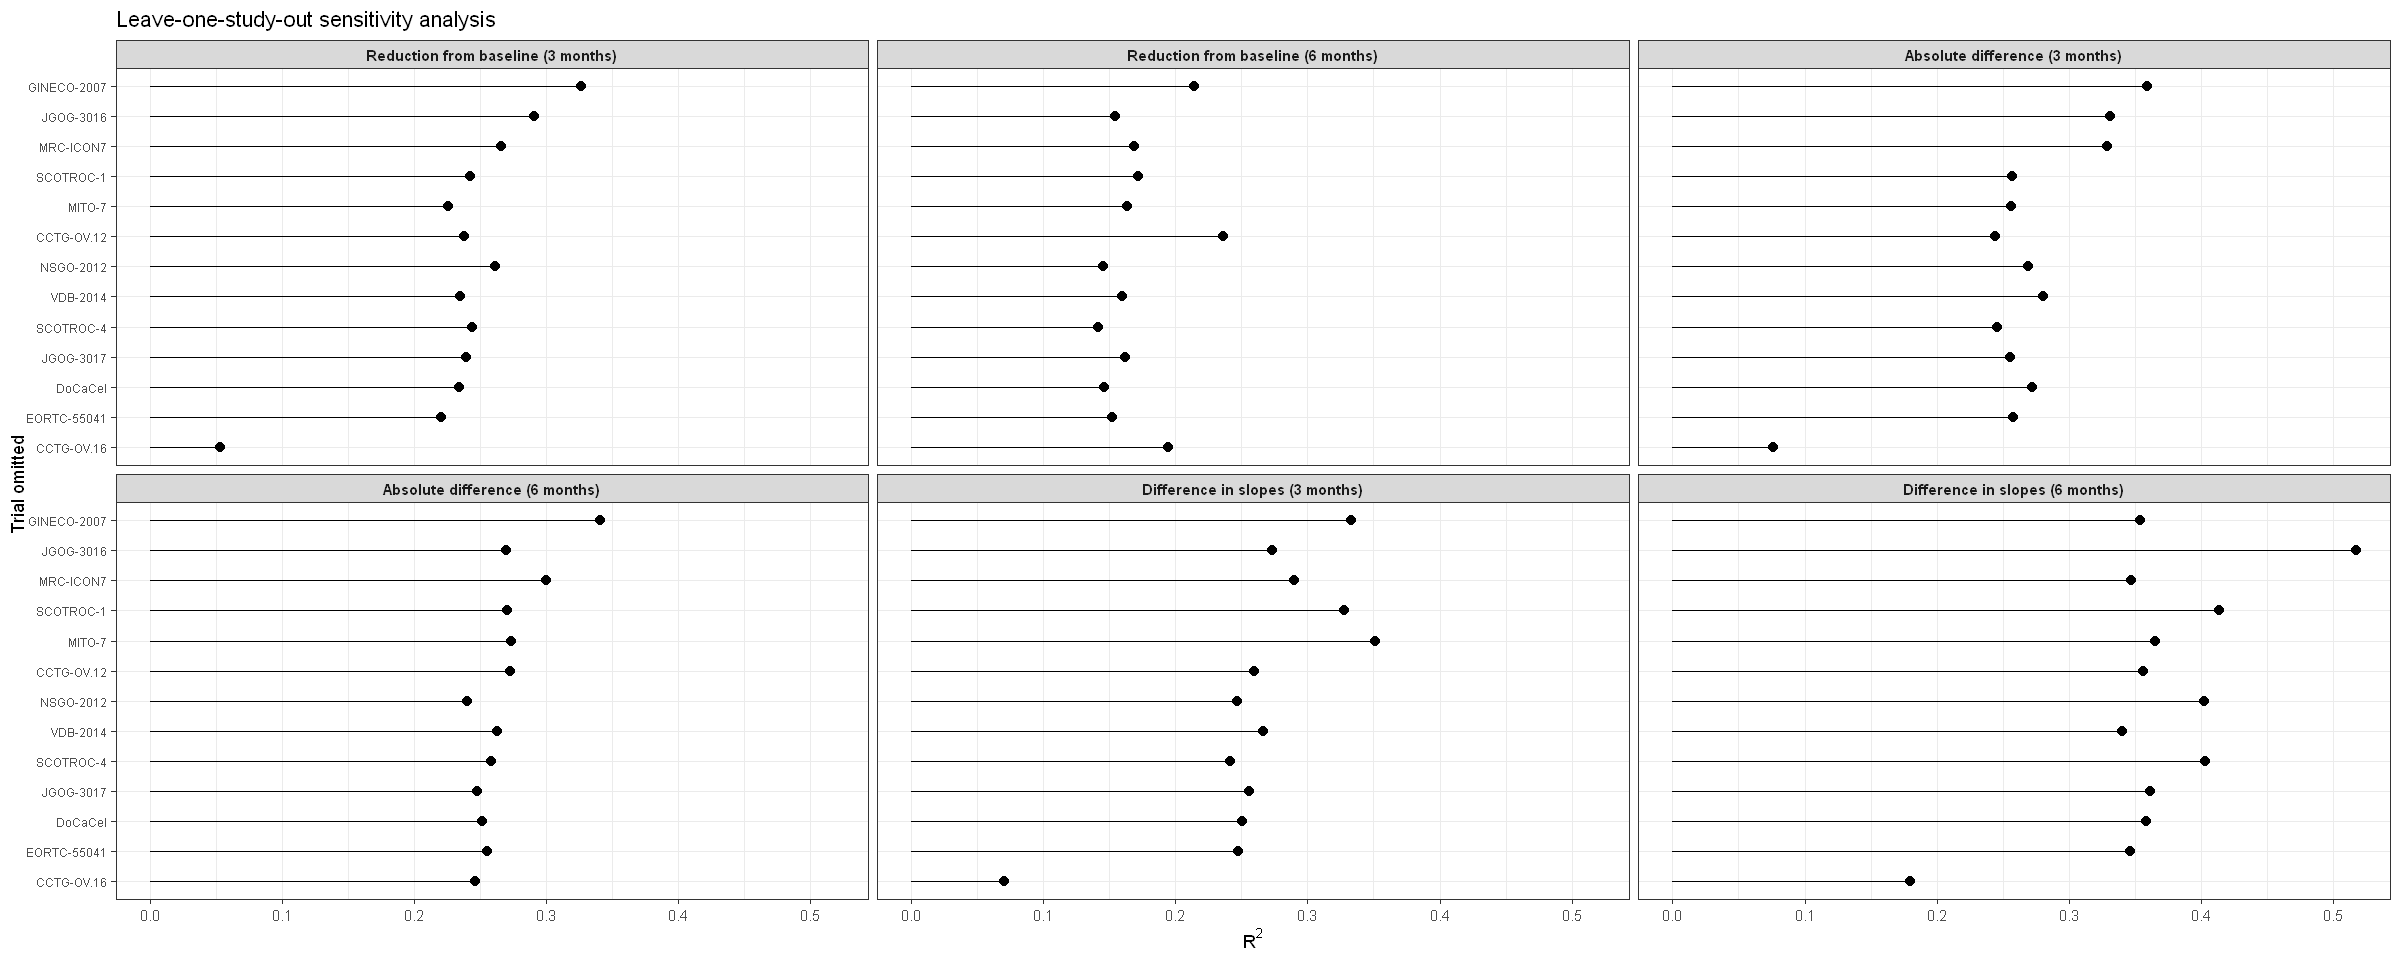

In [ ]:
plot_df <- loso_boot_r2 %>%
  filter(summary %in% c(
    "pct3",
    "abs3",
    "slope3",
    "pct6",
    "abs6",
    "slope6"
  )) %>%
  mutate(
    summary = factor(
      summary,
      levels = c(
        "pct3",
        "pct6",
        "abs3",
        "abs6",
        "slope3",
        "slope6"
      ),
      labels = c(
        "Reduction from baseline (3 months)",
        "Reduction from baseline (6 months)",
        "Absolute difference (3 months)",
        "Absolute difference (6 months)",
        "Difference in slopes (3 months)",
        "Difference in slopes (6 months)"
      )
    )
  )

ggplot(
  plot_df,
  aes(
    x = reorder(left_out_trial, R2),
    y = R2
  )
) +
  geom_segment(
    aes(
      xend = left_out_trial,
      y = 0,
      yend = R2
    )
  ) +
  geom_point(size = 2.5) +
  coord_flip() +
  facet_wrap(~summary, ncol = 3, scales = "fixed") +
  labs(
    x = "Trial omitted",
    y = expression(R^2),
    title = "Leave-one-study-out sensitivity analysis"
  ) +
  theme_bw() +
  theme(
    strip.text = element_text(face = "bold"),
    axis.text.y = element_text(size = 7)
  )

In [ ]:
# ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
# ca125_all_6_surv<-ca125_all_6[!duplicated(ca125_all_6$id),]
# f1 <- function(x) predict(ns_basis, x)[,1]
# f2 <- function(x) predict(ns_basis, x)[,2]
# f3 <- function(x) predict(ns_basis, x)[,3]
# ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
# ca125_all_6_surv<-ca125_all_6[!duplicated(ca125_all_6$id),]

In [ ]:

# formLong <- log_ca125 ~ f1(time_ca125) + f2(time_ca125) + f3(time_ca125) + trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)+ (f1(time_ca125) + f2(time_ca125)+ f3(time_ca125) |id_num)+(trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)|trialid_num)
# formSurv <- INLA::inla.surv(pfs_time_d, pfs_statut) ~ trt_bin
# model_setup <- joint(
#   formSurv  = list(formSurv),
#   formLong  = list(formLong),
#   dataSurv  = as.data.frame(ca125_all_6),
#   dataLong  = as.data.frame(ca125_all_6),
#   id        = "id_num",
#   timeVar   = "time_ca125",
#   family    = "gaussian",
#   basRisk   = "rw2", 
#   NbasRisk = 50,
#   assoc     = "CS",
#   control   = list(int.strategy = "eb"),
#   run=FALSE
# )

In [ ]:
# # Stacking lengths
# N <- length(model_setup$.args$data$Yjoint[[1]])
# n_long <- nrow(ca125_all_6)
# N <- length(model_setup$.args$data$Yjoint[[1]])
# pad <- rep(NA, N - n_long)

# # Treatment * splines random effects
# model_setup$.args$data$WTrial1 <-c(ca125_all_6$trt_bin * f1(ca125_all_6$time_ca125), pad)
# model_setup$.args$data$WTrial2 <-c(ca125_all_6$trt_bin * f2(ca125_all_6$time_ca125), pad)
# model_setup$.args$data$WTrial3 <-c(ca125_all_6$trt_bin * f3(ca125_all_6$time_ca125), pad)

# # Priors
# prior_prec <- list(prior = "loggamma",param = c(1.5, 0.5))

# # Set environnement
# environment(model_setup$.args$formula)$WTrial1 <- model_setup$.args$data$WTrial1
# environment(model_setup$.args$formula)$WTrial2 <- model_setup$.args$data$WTrial2
# environment(model_setup$.args$formula)$WTrial3 <- model_setup$.args$data$WTrial3
# environment(model_setup$.args$formula)$n_trials <- n_trials
# environment(model_setup$.args$formula)$prior_prec <- prior_prec

# # Add the trial-level random effects to the formula
# model_setup$.args$formula <- update(
#   model_setup$.args$formula,
#   ~ . +f(WTrial1, model = "iid", n = max(model_setup$.args$data$WTrial1), constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(WTrial2, model = "iid", n = max(model_setup$.args$data$WTrial2), constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(WTrial3, model = "iid", n = max(model_setup$.args$data$WTrial3), constr = FALSE, hyper = list(prec = prior_prec))
# )

# # run the model
# model_fit <- joint.run(model_setup)
# saveRDS(model_fit, file = "jointed_inla_pfs.rds")


In [ ]:
# # model
# model_fit <- readRDS("jointed_inla_pfs.rds")
# # print summary
# print(summary(model_fit, sdcor=TRUE))

In [ ]:
# inla.zmarginal(inla.tmarginal(function(x) sqrt(1/x), model_fit$marginals.hyperpar[["Precision for WTrial3"]]))

In [ ]:
# ca125_all_6$pfs_statut <- as.numeric(as.character(ca125_all_6$pfs_statut))
# ca125_all_6_surv$pfs_statut <- as.numeric(as.character(ca125_all_6_surv$pfs_statut))
# ca125_all_6$id_num <- as.integer(factor(ca125_all_6$id_num))
# ca125_all_6_surv$id_num <- as.integer(factor(ca125_all_6_surv$id_num))
# P <- predict(
#   model_fit,
#   newData = ca125_all_6,        # longitudinal only
#   newDataSurv = ca125_all_6_surv, # survival only (ONE row per id)
#   horizon = 550,
#   survival = TRUE
# )
# str(P)